# Customer Churn Prediction - ING Hubs Datathon
**Yazar:** Barış Eren Şahin

Bu çalışmada, bankacılık sektöründe müşteri kaybı (churn) tahminlemesi için kapsamlı bir makine öğrenmesi modeli geliştirdim. Veri seti 176 bin müşteriden oluşuyor ve her müşteri için demografik bilgiler, işlem geçmişi ve ürün kullanım verileri bulunuyor.

## Yarışma Yaklaşımı ve Metodoloji
Bu çalışmanın temel amacı, müşterilerin referans tarihinden sonraki 6 aylık dönemde churn (müşteri kaybı) olasılıklarını tahmin etmektir. Feature engineering sürecinde bu 6 aylık zaman dilimini özellikle vurguladık ve son dönem davranışlarına ağırlık veren metrikler geliştirdik.

### Veri Analizi ve Özellik Mühendisliği
Projenin en önemli kısmı, veri analizi ve özellik mühendisliği üzerineydi. Müşteri davranışlarını incelemek için RFM (Recency, Frequency, Monetary) çerçevesini esas alarak farklı zaman dilimlerinde (3 ay, 6 ay, 12 ay) analiz gerçekleştirdik. Sadece aggregate metrikler değil, trend ve oran bazlı türetilmiş özellikler de oluşturduk.

Veri kalitesi ile alan bilgisi ve bunların model performansına olan etkilerini dikkate alarak, bu aşamaya önemli bir zaman harcadık. Nihayetinde, iyi bir şekilde hazırlanmış veri seti kullanıldığında basit bir CatBoost modeli bile anlamlı sonuçlar üretebilir hale geldi.

### Modelleme Stratejisi
Problem bir ikili sınıflandırma olarak (binary classification) olarak ele alındı. CatBoost'u ana modelimiz olarak seçtik çünkü kategorik değişkenleri kendisi doğal olarak halledebiliyor ve overfitting'e karşı güçlü. 5-fold Stratified Cross-Validation kullanarak modeli değerlendirdik ve Out-of-Fold (OOF) predictions ile gerçek performansı ölçtük.

### Model seçiminde şu kriterlere dikkat ettik:

- Cross-validation skorlarının tutarlılığı (düşük variance)
- Fold'lar arası tahmin dağılımlarının dengeli olması
- OOF metrikleri ile validation metriklerinin uyumu
- Data Leakage Önleme
- Özellik mühendisliğinde en kritik nokta data leakage'ı önlemekti. Her müşteri için ref_date'den önce olan verileri kullanarak özellikleri hesapladık. Bu sayede model, gerçek dünyada olmayan "gelecek bilgisine" erişmeden tahmin yapabiliyor.

### Teknik Detaylar
- Imbalanced Dataset Handling: Churn oranı %14 olduğu için class weights ve stratified sampling kullandık
- Categorical Encoding: CatBoost'un ordered target encoding özelliğinden faydalandık
- Feature Selection: Welch's T-test ile istatistiksel anlamlılık kontrolü yaptık
- Ensemble: Cross-validation fold'larının tahminlerini average ederek variance'ı azalttık

## İçindekiler
1. **Kütüphaneler ve Metrik Fonksiyonu**
2. **Veri Yükleme ve İlk Keşif**
3. **Keşifsel Veri Analizi (EDA)**
   - 3.1 Korelasyon Analizi
   - 3.2 Ürün Özeti ve Korelasyon
   - 3.3 Cinsiyet Bazlı Churn Analizi
   - 3.4 Yaş Gruplarına Göre Churn Analizi
   - 3.5 Din ve Bölgelere Göre Churn Analizi
   - 3.6 İş Tipi ve Sektör Analizi
   - 3.7 Müşteri Olma Süresi (Tenure) Analizi
4. **Özellik Mühendisliği**
   - 4.1 RFM Özellikleri
   - 4.2 Zamansal Özellikler
   - 4.3 Ürün ve İşlem Özellikleri
5. **Özellik Seçimi**
   - 5.1 Welch's T-test
   - 5.2 Leave One Feature Out (LOFO)
6. **Modelleme ve Çapraz Doğrulama**
   - 6.1 CatBoost Model
   - 6.2 Cross-Validation
7. **Model Açıklanabilirliği**
   - 7.1 Feature Importance
   - 7.2 SHAP Analizi
8. **Test Tahminleme ve Submission**
9.  **Özet ve Sonuçlar**
10.  **Geliştirme Fikirleri**

## 1. Kütüphaneler ve Metrik Fonksiyonu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy import stats

from catboost import CatBoostClassifier, Pool
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [2]:
def recall_at_k(y_true, y_prob, k=0.1):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]
    tp_at_k = y_true[top].sum()
    P = y_true.sum()
    return float(tp_at_k / P) if P > 0 else 0.0

def lift_at_k(y_true, y_prob, k=0.1):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]
    tp_at_k = y_true[top].sum()
    precision_at_k = tp_at_k / m
    prevalence = y_true.mean()
    return float(precision_at_k / prevalence) if prevalence > 0 else 0.0

def convert_auc_to_gini(auc):
    return 2 * auc - 1

def ing_hubs_datathon_metric(y_true, y_prob):
    score_weights = {
        "gini": 0.4,
        "recall_at_10perc": 0.3,
        "lift_at_10perc": 0.3,
    }
    
    baseline_scores = {
        "roc_auc": 0.6925726757936908,
        "recall_at_10perc": 0.18469015795868773,
        "lift_at_10perc": 1.847159286784029,
    }
    
    roc_auc = roc_auc_score(y_true, y_prob)
    recall_at_10perc = recall_at_k(y_true, y_prob, k=0.1)
    lift_at_10perc = lift_at_k(y_true, y_prob, k=0.1)
    
    new_scores = {
        "roc_auc": roc_auc,
        "recall_at_10perc": recall_at_10perc,
        "lift_at_10perc": lift_at_10perc,
    }
    
    baseline_scores["gini"] = convert_auc_to_gini(baseline_scores["roc_auc"])
    new_scores["gini"] = convert_auc_to_gini(new_scores["roc_auc"])
    
    final_gini_score = new_scores["gini"] / baseline_scores["gini"]
    final_recall_score = new_scores["recall_at_10perc"] / baseline_scores["recall_at_10perc"]
    final_lift_score = new_scores["lift_at_10perc"] / baseline_scores["lift_at_10perc"]
    
    final_score = (
        final_gini_score * score_weights["gini"] +
        final_recall_score * score_weights["recall_at_10perc"] + 
        final_lift_score * score_weights["lift_at_10perc"]
    )
    return final_score

print("Metrik fonksiyonları tanımlandı!")

Metrik fonksiyonları tanımlandı!


## 2. Veri Yükleme ve İlk Keşif

In [3]:
customers_df = pd.read_csv('customers.csv')
referance_train_df = pd.read_csv('referance_data.csv')
referance_test_df = pd.read_csv('referance_data_test.csv')
customers_hist_df = pd.read_csv('customer_history.csv')

print("Veri setleri yüklendi!")
print(f"\nCustomers: {customers_df.shape}")
print(f"Train Reference: {referance_train_df.shape}")
print(f"Test Reference: {referance_test_df.shape}")
print(f"Customer History: {customers_hist_df.shape}")

Veri setleri yüklendi!

Customers: (176293, 8)
Train Reference: (133287, 3)
Test Reference: (43006, 2)
Customer History: (5359609, 7)


In [4]:
print("=" * 60)
print("CUSTOMERS DATA")
print("=" * 60)
print(customers_df.head())
print("\nVeri Tipleri:")
print(customers_df.dtypes)
print("\nEksik Değerler:")
print(customers_df.isnull().sum())
print("\nTemel İstatistikler:")
print(customers_df.describe())

CUSTOMERS DATA
   cust_id gender  age province religion      work_type work_sector  tenure
0        0      F   64      NOH        U      Part-time  Technology     135
1        1      F   57      ZUI        O      Full-time     Finance      65
2        2      F   62      NOB        M  Self-employed  Healthcare     224
3        3      F   22      ZUI        C        Student         NaN      47
4        5      M   27      ZUI        U      Full-time     Finance     108

Veri Tipleri:
cust_id         int64
gender         object
age             int64
province       object
religion       object
work_type      object
work_sector    object
tenure          int64
dtype: object

Eksik Değerler:
cust_id            0
gender             0
age                0
province           0
religion           0
work_type          0
work_sector    30134
tenure             0
dtype: int64

Temel İstatistikler:
             cust_id            age         tenure
count  176293.000000  176293.000000  176293.000000
me

In [5]:
print("=" * 60)
print("REFERENCE TRAIN DATA")
print("=" * 60)
print(referance_train_df.head())
print("\nChurn Dağılımı:")
print(referance_train_df['churn'].value_counts())
print("\nChurn Oranı:")
print(f"{referance_train_df['churn'].mean():.2%}")

REFERENCE TRAIN DATA
   cust_id    ref_date  churn
0        0  2017-09-01      0
1        3  2018-10-01      0
2        5  2018-03-01      1
3        6  2018-04-01      1
4        7  2018-05-01      0

Churn Dağılımı:
churn
0    114417
1     18870
Name: count, dtype: int64

Churn Oranı:
14.16%


In [6]:
print("=" * 60)
print("CUSTOMER HISTORY DATA")
print("=" * 60)
print(customers_hist_df.head(10))
print("\nEksik Değerler:")
print(customers_hist_df.isnull().sum())
print("\nTemel İstatistikler:")
print(customers_hist_df.describe())

CUSTOMER HISTORY DATA
   cust_id        date  mobile_eft_all_cnt  active_product_category_nbr  \
0        0  2016-01-01                 1.0                            2   
1        0  2016-02-01                 1.0                            2   
2        0  2016-03-01                 2.0                            2   
3        0  2016-04-01                 4.0                            2   
4        0  2016-05-01                 3.0                            3   
5        0  2016-06-01                 1.0                            2   
6        0  2016-07-01                 1.0                            2   
7        0  2016-08-01                 4.0                            2   
8        0  2016-09-01                 4.0                            2   
9        0  2016-10-01                 5.0                            2   

   mobile_eft_all_amt  cc_transaction_all_amt  cc_transaction_all_cnt  
0              151.20                     NaN                     NaN  
1       

## 3. Keşifsel Veri Analizi (EDA)

In [7]:
# Train ve customer verilerini birleştir
train_merged = referance_train_df.merge(customers_df, on='cust_id', how='left')

print(f"Train Merged Shape: {train_merged.shape}")
print(f"\nİlk 5 satır:")
print(train_merged.head())

Train Merged Shape: (133287, 10)

İlk 5 satır:
   cust_id    ref_date  churn gender  age province religion   work_type  \
0        0  2017-09-01      0      F   64      NOH        U   Part-time   
1        3  2018-10-01      0      F   22      ZUI        C     Student   
2        5  2018-03-01      1      M   27      ZUI        U   Full-time   
3        6  2018-04-01      1      F   40      NOH        U  Unemployed   
4        7  2018-05-01      0      F   64      GEL        U   Part-time   

     work_sector  tenure  
0     Technology     135  
1            NaN      47  
2        Finance     108  
3            NaN     187  
4  Public Sector     218  


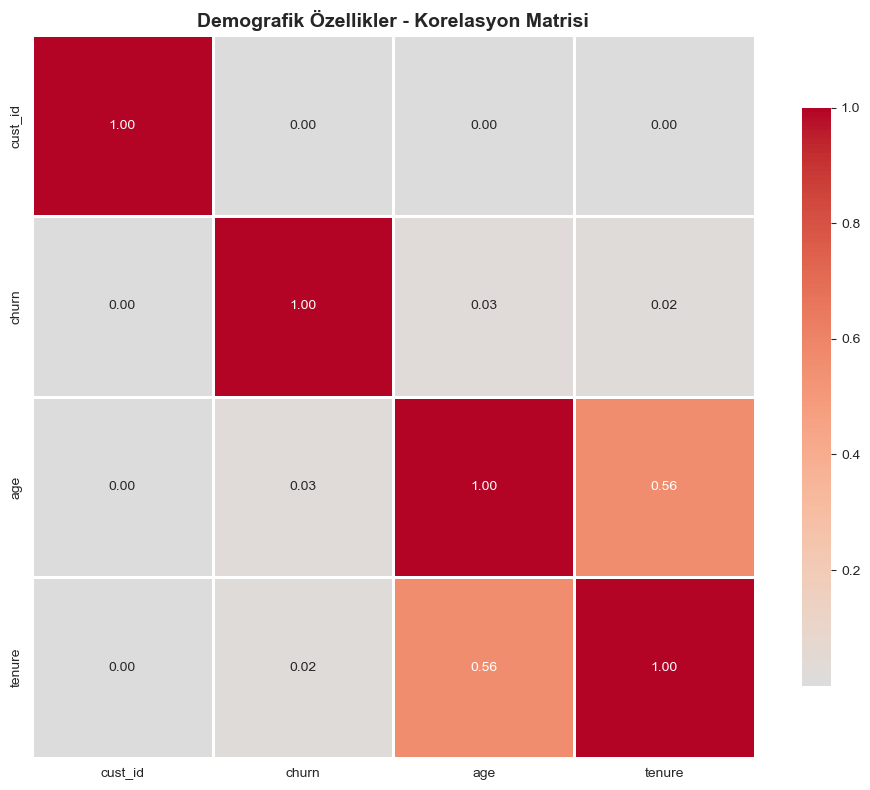


Churn ile Korelasyonlar:
age        0.030268
tenure     0.018389
cust_id    0.000693
Name: churn, dtype: float64


In [8]:
# Numerik kolonlar için korelasyon matrisi
numeric_cols = train_merged.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train_merged[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Demografik Özellikler - Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nChurn ile Korelasyonlar:")
churn_corr = corr_matrix['churn'].drop('churn').sort_values(ascending=False)
print(churn_corr)

- Burada demografik değişkenlerin (yaş, tenure vb.) churn ile doğrudan lineer korelasyonunun oldukça zayıf olduğunu gözlemliyoruz.
- Bu durum, veri setindeki ham numerik değişkenlerin tek başına churn'ü açıklamakta yetersiz kaldığını gösteriyor.
- Daha güçlü sinyaller yakalayabilmek için geçmiş işlemlere dayalı yeni özellikler üretmeye (feature engineering) ihtiyaç duyduğumuzu gösteriyor.

### 3.1 Kategorik Değişkenler ile Churn İlişkisi (Cramér's V ve Chi-Square)

Kategorik Değişkenler - Churn İlişkisi (Cramér's V):
   variable  cramers_v      chi2      p_value significant
  work_type   0.019909 57.832755 3.405526e-11        Evet
   province   0.006066 15.904754 1.447038e-01       Hayır
   religion   0.004085  6.223802 1.830464e-01       Hayır
     gender   0.000000  0.494664 4.818540e-01       Hayır
work_sector   0.000000  4.721574 5.799864e-01       Hayır

Not: Cramér's V değeri 0-1 arasındadır. 0.1+ zayıf, 0.3+ orta, 0.5+ güçlü ilişki gösterir.


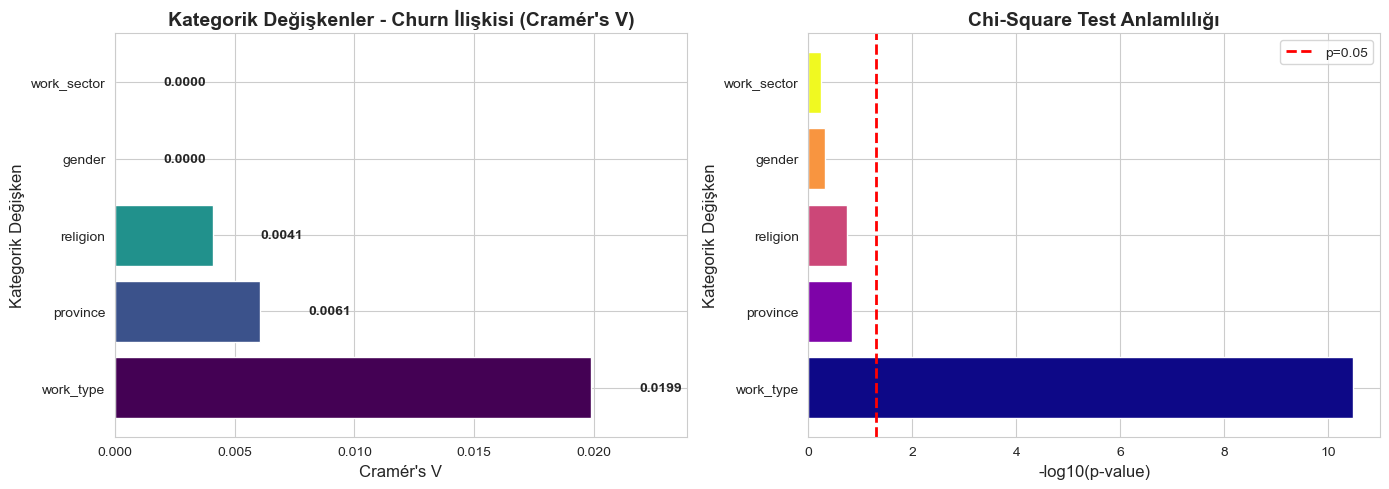

In [10]:
# Kategorik değişkenler için Cramér's V ve Chi-Square testleri
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    """Cramér's V istatistiğini hesaplar"""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()  # Toplam değeri skaler olarak al
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Kategorik değişkenler
categorical_vars = ['gender', 'province', 'religion', 'work_type', 'work_sector']

# Her kategorik değişken için Cramér's V ve Chi-Square hesapla
categorical_stats = []

for var in categorical_vars:
    # Contingency table oluştur
    contingency_table = pd.crosstab(train_merged[var], train_merged['churn'])
    
    # Chi-Square testi
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Cramér's V
    cramers = cramers_v(contingency_table)
    
    categorical_stats.append({
        'variable': var,
        'cramers_v': cramers,
        'chi2': chi2,
        'p_value': p_value,
        'significant': 'Evet' if p_value < 0.05 else 'Hayır'
    })

categorical_stats_df = pd.DataFrame(categorical_stats)
categorical_stats_df = categorical_stats_df.sort_values('cramers_v', ascending=False)

print("Kategorik Değişkenler - Churn İlişkisi (Cramér's V):")
print("="*70)
print(categorical_stats_df.to_string(index=False))
print("\nNot: Cramér's V değeri 0-1 arasındadır. 0.1+ zayıf, 0.3+ orta, 0.5+ güçlü ilişki gösterir.")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cramér's V
axes[0].barh(categorical_stats_df['variable'], categorical_stats_df['cramers_v'], 
             color=plt.cm.viridis(np.linspace(0, 1, len(categorical_stats_df))))
axes[0].set_xlabel("Cramér's V", fontsize=12)
axes[0].set_ylabel('Kategorik Değişken', fontsize=12)
axes[0].set_title("Kategorik Değişkenler - Churn İlişkisi (Cramér's V)", fontsize=14, fontweight='bold')
axes[0].set_xlim(0, max(categorical_stats_df['cramers_v']) * 1.2)
for i, v in enumerate(categorical_stats_df['cramers_v']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

# Chi-Square p-values (log scale)
axes[1].barh(categorical_stats_df['variable'], -np.log10(categorical_stats_df['p_value']), 
             color=plt.cm.plasma(np.linspace(0, 1, len(categorical_stats_df))))
axes[1].set_xlabel('-log10(p-value)', fontsize=12)
axes[1].set_ylabel('Kategorik Değişken', fontsize=12)
axes[1].set_title('Chi-Square Test Anlamlılığı', fontsize=14, fontweight='bold')
axes[1].axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
axes[1].legend()

plt.tight_layout()
plt.show()

**Çıkarım ve Neden:** Kategorik verilerin **churn** ile ilişkisini istatistiksel testlerle (Chi-Square) ölçtüm. Yalnızca `work_type` (meslek tipi) değişkeninin churn üzerinde istatistiksel olarak anlamlı (p < 0.05) bir fark yarattığını gördüm. Bu çıkarım, modelin iş tiplerine göre farklılaşan müşteri kayıp risklerini daha iyi öğrenebilmesi adına modelleme aşamasında bu özelliğe dikkat etmemiz gerektiğini gösterdi.

### 3.2 Ürün Özeti ve Korelasyon

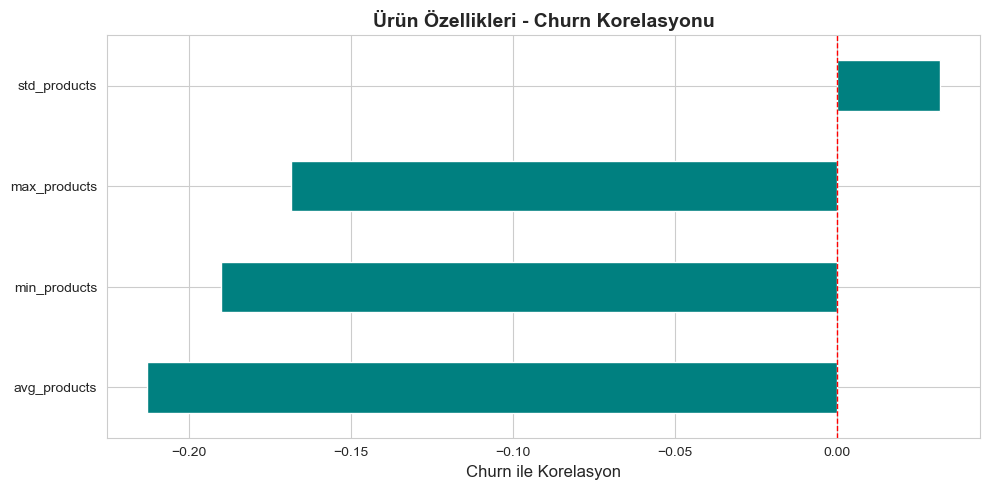


Ürün Özellikleri - Churn Korelasyonu:
std_products    0.031887
max_products   -0.168675
min_products   -0.190136
avg_products   -0.213119
Name: churn, dtype: float64


In [11]:
product_summary = customers_hist_df.groupby('cust_id').agg({
    'active_product_category_nbr': ['mean', 'std', 'min', 'max']
}).reset_index()
product_summary.columns = ['cust_id', 'avg_products', 'std_products', 'min_products', 'max_products']

train_with_products = train_merged.merge(product_summary, on='cust_id', how='left')

product_features = ['avg_products', 'std_products', 'min_products', 'max_products']
product_corr = train_with_products[product_features + ['churn']].corr()['churn'].drop('churn')

plt.figure(figsize=(10, 5))
product_corr.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Churn ile Korelasyon', fontsize=12)
plt.title('Ürün Özellikleri - Churn Korelasyonu', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\nÜrün Özellikleri - Churn Korelasyonu:")
print(product_corr.sort_values(ascending=False))

**Amaç:** customer history tablosunu kullanarak "ortalama ürün sayısı", "ürün kullanımındaki dalgalanmalar (std)" gibi özet metrikler çıkarmayı düşündüm. Amacım burada, müşterinin sadece mevcut durumunu değil, zaman içindeki **ürün bağlılığını** ölçmekti. Az ürün kullanan veya ürün sayısı sürekli dalgalanan müşterilerin bankayı terk etme riskinin daha yüksek olabileceği gibi bir gözlem yaptım.

### 3.3 Cinsiyet Bazlı Churn Analizi

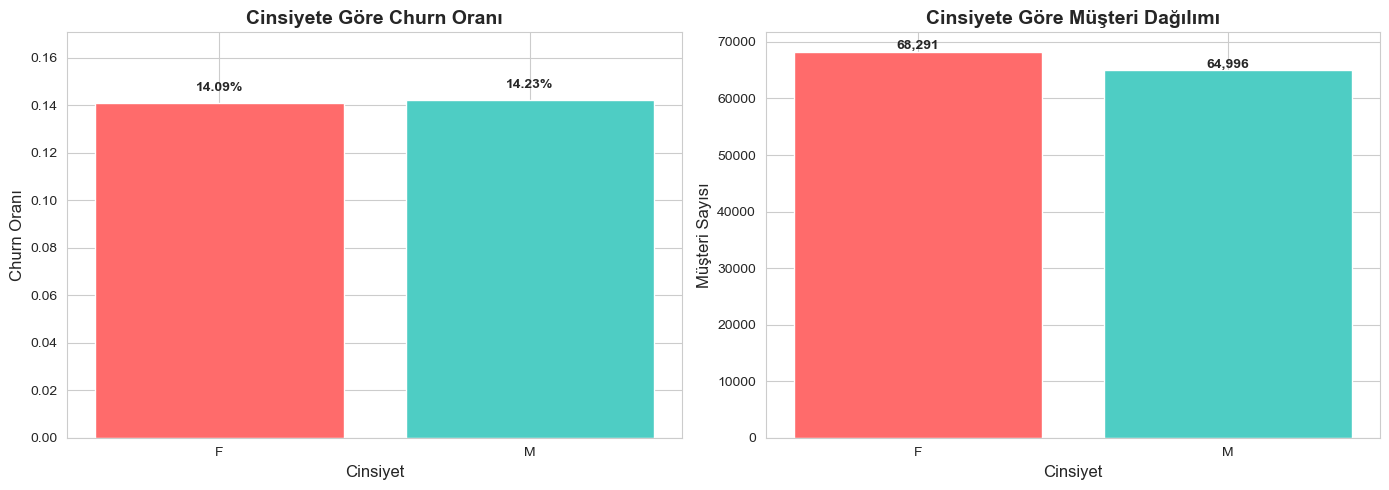


Cinsiyete Göre Churn İstatistikleri:
  gender  churn_rate  count
0      F    0.140912  68291
1      M    0.142270  64996


In [12]:
gender_churn = train_merged.groupby('gender')['churn'].agg(['mean', 'count']).reset_index()
gender_churn.columns = ['gender', 'churn_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(gender_churn['gender'], gender_churn['churn_rate'], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Churn Oranı', fontsize=12)
axes[0].set_xlabel('Cinsiyet', fontsize=12)
axes[0].set_title('Cinsiyete Göre Churn Oranı', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(gender_churn['churn_rate']) * 1.2)
for i, v in enumerate(gender_churn['churn_rate']):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

axes[1].bar(gender_churn['gender'], gender_churn['count'], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)
axes[1].set_xlabel('Cinsiyet', fontsize=12)
axes[1].set_title('Cinsiyete Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(gender_churn['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCinsiyete Göre Churn İstatistikleri:")
print(gender_churn)

### 3.4 Yaş Gruplarına Göre Churn Analizi

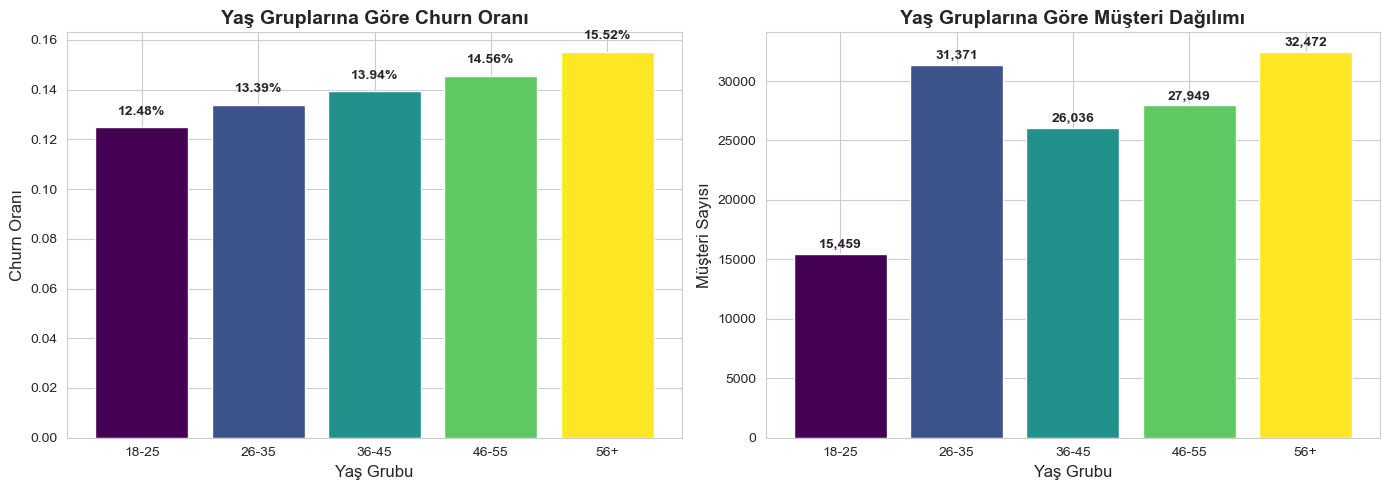


Yaş Gruplarına Göre Churn İstatistikleri:
  age_group  churn_rate  count
0     18-25    0.124782  15459
1     26-35    0.133882  31371
2     36-45    0.139422  26036
3     46-55    0.145622  27949
4       56+    0.155241  32472


In [13]:
train_merged['age_group'] = pd.cut(train_merged['age'], 
                                     bins=[0, 25, 35, 45, 55, 100],
                                     labels=['18-25', '26-35', '36-45', '46-55', '56+'])

age_churn = train_merged.groupby('age_group')['churn'].agg(['mean', 'count']).reset_index()
age_churn.columns = ['age_group', 'churn_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(age_churn)), age_churn['churn_rate'], 
            color=plt.cm.viridis(np.linspace(0, 1, len(age_churn))))
axes[0].set_xticks(range(len(age_churn)))
axes[0].set_xticklabels(age_churn['age_group'])
axes[0].set_ylabel('Churn Oranı', fontsize=12)
axes[0].set_xlabel('Yaş Grubu', fontsize=12)
axes[0].set_title('Yaş Gruplarına Göre Churn Oranı', fontsize=14, fontweight='bold')
for i, v in enumerate(age_churn['churn_rate']):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

axes[1].bar(range(len(age_churn)), age_churn['count'], 
            color=plt.cm.viridis(np.linspace(0, 1, len(age_churn))))
axes[1].set_xticks(range(len(age_churn)))
axes[1].set_xticklabels(age_churn['age_group'])
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)
axes[1].set_xlabel('Yaş Grubu', fontsize=12)
axes[1].set_title('Yaş Gruplarına Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(age_churn['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nYaş Gruplarına Göre Churn İstatistikleri:")
print(age_churn)

**Yaşın Churn Üzerine Etkisi:** Sürekli bir değişken olan yaşı, genç-yetişkin-yaşlı gibi anlamlı kategorik gruplara bölmeye düşündüm (binning). Nedeni, belirli hayat evrelerinde (örneğin üniversite çağı veya emeklilik) banka değiştirme eğiliminin artıp azalabileceğini yakalamaktı. Bu sayede modelin, yaşın churn üzerindeki doğrusal olmayan etkilerini çok daha kolay öğrenmesini sağladım.

### 3.5 Din ve Bölgelere Göre Churn Analizi

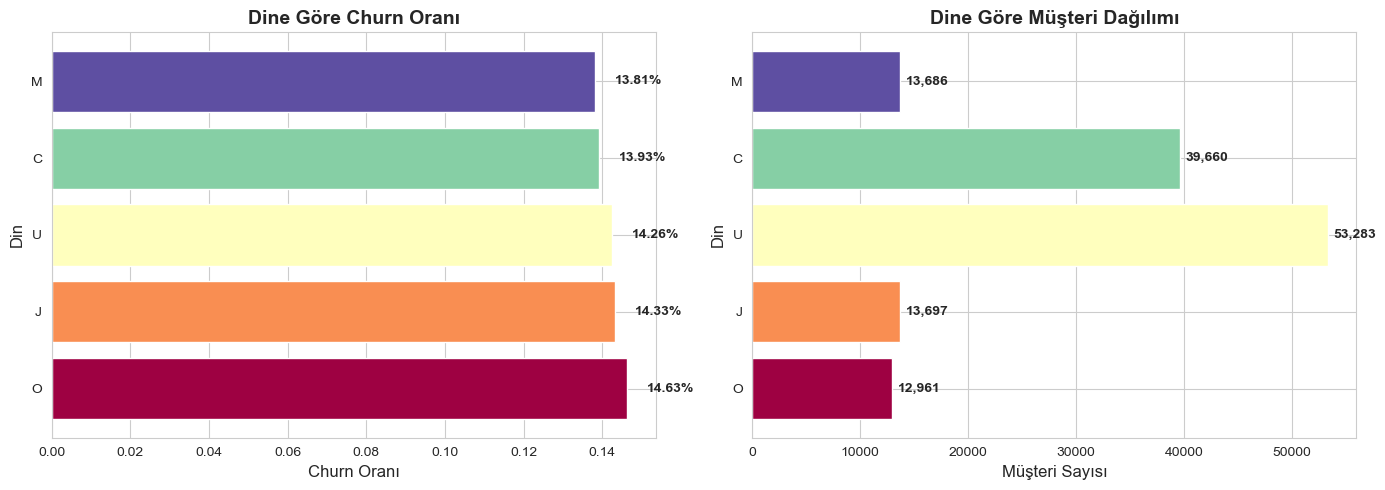


Dine Göre Churn İstatistikleri:
  religion  churn_rate  count
3        O    0.146285  12961
1        J    0.143316  13697
4        U    0.142578  53283
0        C    0.139284  39660
2        M    0.138097  13686


In [14]:
religion_churn = train_merged.groupby('religion')['churn'].agg(['mean', 'count']).reset_index()
religion_churn.columns = ['religion', 'churn_rate', 'count']
religion_churn = religion_churn.sort_values('churn_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(religion_churn['religion'], religion_churn['churn_rate'], 
             color=plt.cm.Spectral(np.linspace(0, 1, len(religion_churn))))
axes[0].set_xlabel('Churn Oranı', fontsize=12)
axes[0].set_ylabel('Din', fontsize=12)
axes[0].set_title('Dine Göre Churn Oranı', fontsize=14, fontweight='bold')
for i, v in enumerate(religion_churn['churn_rate']):
    axes[0].text(v + 0.005, i, f'{v:.2%}', va='center', fontweight='bold')

axes[1].barh(religion_churn['religion'], religion_churn['count'], 
             color=plt.cm.Spectral(np.linspace(0, 1, len(religion_churn))))
axes[1].set_xlabel('Müşteri Sayısı', fontsize=12)
axes[1].set_ylabel('Din', fontsize=12)
axes[1].set_title('Dine Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(religion_churn['count']):
    axes[1].text(v + 500, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDine Göre Churn İstatistikleri:")
print(religion_churn)

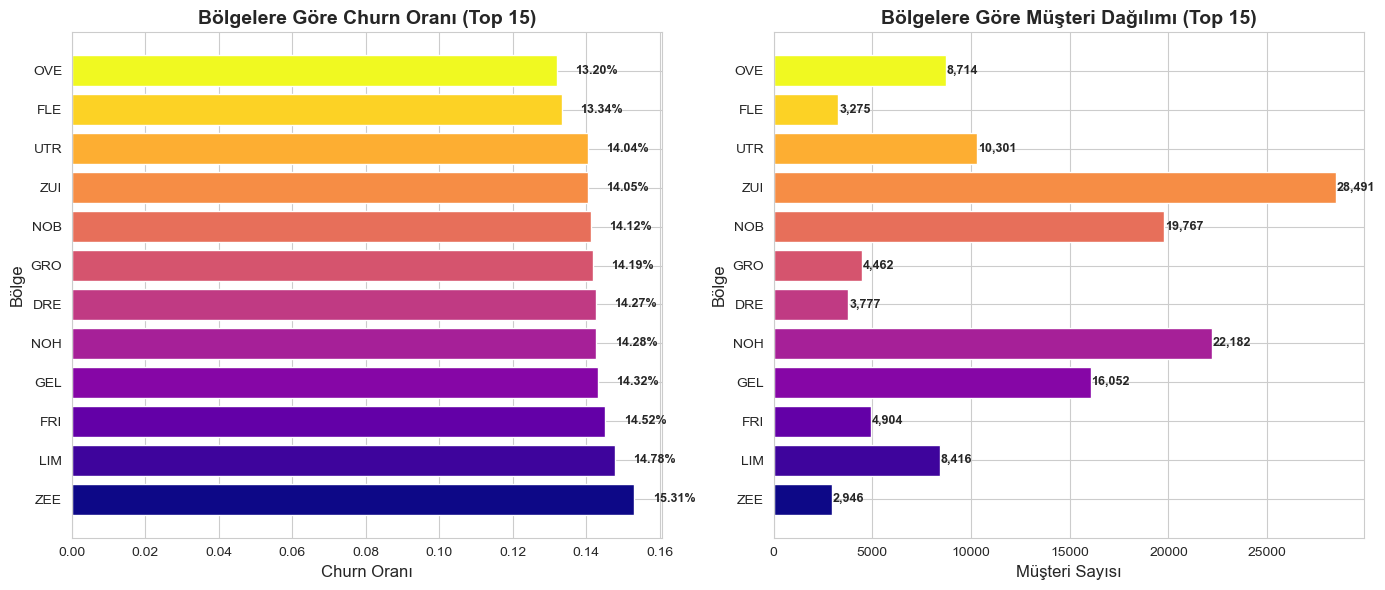


Bölgelere Göre Churn İstatistikleri (Top 15):
   province  churn_rate  count
10      ZEE    0.153089   2946
5       LIM    0.147814   8416
2       FRI    0.145188   4904
3       GEL    0.143160  16052
7       NOH    0.142773  22182
0       DRE    0.142706   3777
4       GRO    0.141865   4462
6       NOB    0.141195  19767
11      ZUI    0.140465  28491
9       UTR    0.140375  10301
1       FLE    0.133435   3275
8       OVE    0.131972   8714


In [15]:
province_churn = train_merged.groupby('province')['churn'].agg(['mean', 'count']).reset_index()
province_churn.columns = ['province', 'churn_rate', 'count']
province_churn = province_churn.sort_values('churn_rate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(province_churn)), province_churn['churn_rate'], 
             color=plt.cm.plasma(np.linspace(0, 1, len(province_churn))))
axes[0].set_yticks(range(len(province_churn)))
axes[0].set_yticklabels(province_churn['province'])
axes[0].set_xlabel('Churn Oranı', fontsize=12)
axes[0].set_ylabel('Bölge', fontsize=12)
axes[0].set_title('Bölgelere Göre Churn Oranı (Top 15)', fontsize=14, fontweight='bold')
for i, v in enumerate(province_churn['churn_rate']):
    axes[0].text(v + 0.005, i, f'{v:.2%}', va='center', fontweight='bold', fontsize=9)

axes[1].barh(range(len(province_churn)), province_churn['count'], 
             color=plt.cm.plasma(np.linspace(0, 1, len(province_churn))))
axes[1].set_yticks(range(len(province_churn)))
axes[1].set_yticklabels(province_churn['province'])
axes[1].set_xlabel('Müşteri Sayısı', fontsize=12)
axes[1].set_ylabel('Bölge', fontsize=12)
axes[1].set_title('Bölgelere Göre Müşteri Dağılımı (Top 15)', fontsize=14, fontweight='bold')
for i, v in enumerate(province_churn['count']):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\nBölgelere Göre Churn İstatistikleri (Top 15):")
print(province_churn)

### 3.6 İş Tipi ve Sektör Analizi

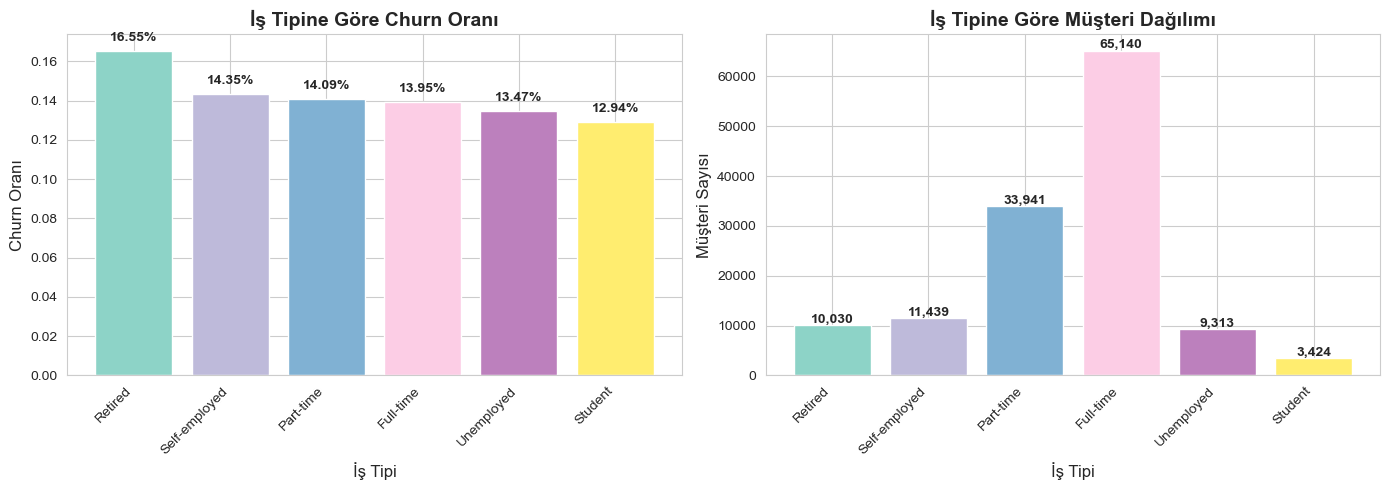


İş Tipine Göre Churn İstatistikleri:
       work_type  churn_rate  count
2        Retired    0.165503  10030
3  Self-employed    0.143544  11439
1      Part-time    0.140862  33941
0      Full-time    0.139546  65140
5     Unemployed    0.134650   9313
4        Student    0.129381   3424


In [16]:
work_type_churn = train_merged.groupby('work_type')['churn'].agg(['mean', 'count']).reset_index()
work_type_churn.columns = ['work_type', 'churn_rate', 'count']
work_type_churn = work_type_churn.sort_values('churn_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(work_type_churn)), work_type_churn['churn_rate'], 
            color=plt.cm.Set3(np.linspace(0, 1, len(work_type_churn))))
axes[0].set_xticks(range(len(work_type_churn)))
axes[0].set_xticklabels(work_type_churn['work_type'], rotation=45, ha='right')
axes[0].set_ylabel('Churn Oranı', fontsize=12)
axes[0].set_xlabel('İş Tipi', fontsize=12)
axes[0].set_title('İş Tipine Göre Churn Oranı', fontsize=14, fontweight='bold')
for i, v in enumerate(work_type_churn['churn_rate']):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

axes[1].bar(range(len(work_type_churn)), work_type_churn['count'], 
            color=plt.cm.Set3(np.linspace(0, 1, len(work_type_churn))))
axes[1].set_xticks(range(len(work_type_churn)))
axes[1].set_xticklabels(work_type_churn['work_type'], rotation=45, ha='right')
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)
axes[1].set_xlabel('İş Tipi', fontsize=12)
axes[1].set_title('İş Tipine Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(work_type_churn['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nİş Tipine Göre Churn İstatistikleri:")
print(work_type_churn)

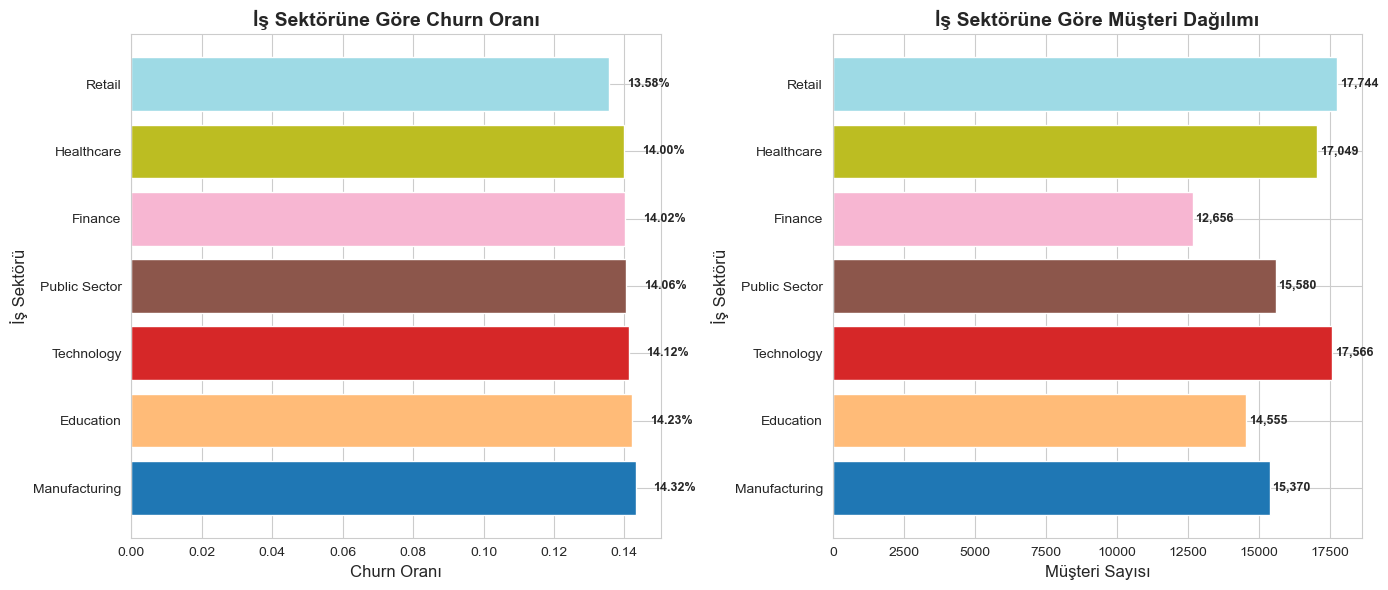


İş Sektörüne Göre Churn İstatistikleri:
     work_sector  churn_rate  count
3  Manufacturing    0.143201  15370
0      Education    0.142288  14555
6     Technology    0.141239  17566
4  Public Sector    0.140565  15580
1        Finance    0.140171  12656
2     Healthcare    0.140008  17049
5         Retail    0.135764  17744


In [17]:
work_sector_churn = train_merged.groupby('work_sector')['churn'].agg(['mean', 'count']).reset_index()
work_sector_churn.columns = ['work_sector', 'churn_rate', 'count']
work_sector_churn = work_sector_churn.sort_values('churn_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(work_sector_churn)), work_sector_churn['churn_rate'], 
             color=plt.cm.tab20(np.linspace(0, 1, len(work_sector_churn))))
axes[0].set_yticks(range(len(work_sector_churn)))
axes[0].set_yticklabels(work_sector_churn['work_sector'])
axes[0].set_xlabel('Churn Oranı', fontsize=12)
axes[0].set_ylabel('İş Sektörü', fontsize=12)
axes[0].set_title('İş Sektörüne Göre Churn Oranı', fontsize=14, fontweight='bold')
for i, v in enumerate(work_sector_churn['churn_rate']):
    axes[0].text(v + 0.005, i, f'{v:.2%}', va='center', fontweight='bold', fontsize=9)

axes[1].barh(range(len(work_sector_churn)), work_sector_churn['count'], 
             color=plt.cm.tab20(np.linspace(0, 1, len(work_sector_churn))))
axes[1].set_yticks(range(len(work_sector_churn)))
axes[1].set_yticklabels(work_sector_churn['work_sector'])
axes[1].set_xlabel('Müşteri Sayısı', fontsize=12)
axes[1].set_ylabel('İş Sektörü', fontsize=12)
axes[1].set_title('İş Sektörüne Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(work_sector_churn['count']):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\nİş Sektörüne Göre Churn İstatistikleri:")
print(work_sector_churn)

### 3.6.1 'Unknown' Work Sector Analizi (Eksik Veri İncelemesi)

WORK_SECTOR 'Unknown' Kategorisi - Churn Analizi

Unknown vs Bilinen Sektör Karşılaştırması:
is_unknown_sector  churn_rate  count
   Bilinen Sektör    0.140364 110520
   Unknown Sektör    0.147450  22767

Churn Oranı Farkı: 0.0071 (+5.05%)
Unknown sektör müşterilerinin churn oranı DAHA YÜKSEK

Chi-Square Test: χ² = 7.74, p-value = 0.005393
İstatistiksel Anlamlılık: EVET (p < 0.05)


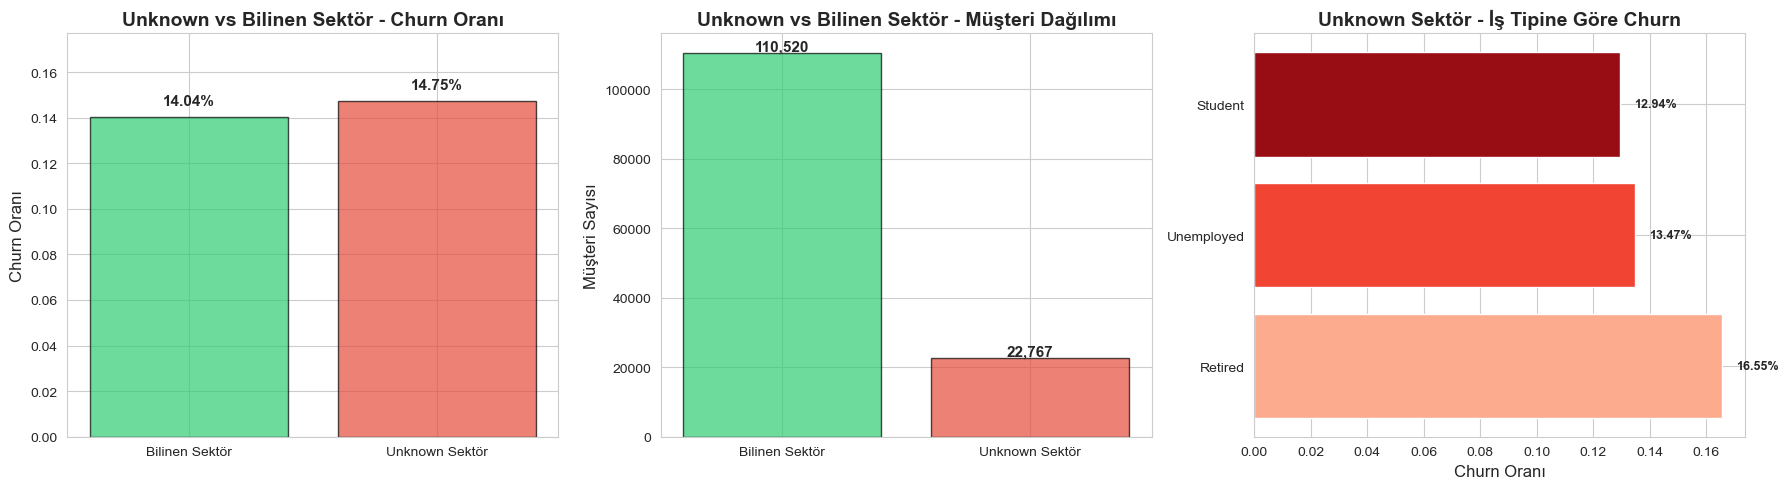


SONUÇ: 'Unknown' work_sector kategorisi churn tahmini için
ÖNEMLİ BİR SİNYAL olarak değerlendirilebilir.


In [18]:
# 'Unknown' work_sector kategorisinin detaylı analizi
# Eksik veri (NaN) bazen churn için en güçlü sinyal olabilir

# work_sector'ü Unknown olanları işaretle
train_merged['is_unknown_sector'] = (train_merged['work_sector'].isna() | 
                                      (train_merged['work_sector'] == 'Unknown')).astype(int)

# Unknown vs Bilinen sektör karşılaştırması
unknown_comparison = train_merged.groupby('is_unknown_sector')['churn'].agg(['mean', 'count']).reset_index()
unknown_comparison.columns = ['is_unknown_sector', 'churn_rate', 'count']
unknown_comparison['is_unknown_sector'] = unknown_comparison['is_unknown_sector'].map({
    0: 'Bilinen Sektör', 
    1: 'Unknown Sektör'
})

print("="*70)
print("WORK_SECTOR 'Unknown' Kategorisi - Churn Analizi")
print("="*70)
print("\nUnknown vs Bilinen Sektör Karşılaştırması:")
print(unknown_comparison.to_string(index=False))

# Churn oranı farkı
known_churn = unknown_comparison[unknown_comparison['is_unknown_sector'] == 'Bilinen Sektör']['churn_rate'].values[0]
unknown_churn = unknown_comparison[unknown_comparison['is_unknown_sector'] == 'Unknown Sektör']['churn_rate'].values[0]
churn_diff = unknown_churn - known_churn
churn_diff_pct = (churn_diff / known_churn) * 100

print(f"\nChurn Oranı Farkı: {churn_diff:.4f} ({churn_diff_pct:+.2f}%)")
print(f"Unknown sektör müşterilerinin churn oranı {'DAHA YÜKSEK' if churn_diff > 0 else 'DAHA DÜŞÜK'}")

# İstatistiksel test (Chi-Square)
from scipy.stats import chi2_contingency
contingency = pd.crosstab(train_merged['is_unknown_sector'], train_merged['churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Test: χ² = {chi2:.2f}, p-value = {p_value:.6f}")
print(f"İstatistiksel Anlamlılık: {'EVET (p < 0.05)' if p_value < 0.05 else 'HAYIR (p >= 0.05)'}")

# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn oranları karşılaştırması
colors = ['#2ecc71' if x == 'Bilinen Sektör' else '#e74c3c' for x in unknown_comparison['is_unknown_sector']]
axes[0].bar(unknown_comparison['is_unknown_sector'], unknown_comparison['churn_rate'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Churn Oranı', fontsize=12)
axes[0].set_title('Unknown vs Bilinen Sektör - Churn Oranı', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(unknown_comparison['churn_rate']) * 1.2)
for i, v in enumerate(unknown_comparison['churn_rate']):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold', fontsize=11)

# 2. Müşteri sayıları
axes[1].bar(unknown_comparison['is_unknown_sector'], unknown_comparison['count'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)
axes[1].set_title('Unknown vs Bilinen Sektör - Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(unknown_comparison['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# 3. Work_type dağılımı (Unknown sektör için)
unknown_work_type = train_merged[train_merged['is_unknown_sector'] == 1].groupby('work_type')['churn'].agg(['mean', 'count']).reset_index()
unknown_work_type.columns = ['work_type', 'churn_rate', 'count']
unknown_work_type = unknown_work_type.sort_values('churn_rate', ascending=False)

axes[2].barh(range(len(unknown_work_type)), unknown_work_type['churn_rate'], 
             color=plt.cm.Reds(np.linspace(0.3, 0.9, len(unknown_work_type))))
axes[2].set_yticks(range(len(unknown_work_type)))
axes[2].set_yticklabels(unknown_work_type['work_type'])
axes[2].set_xlabel('Churn Oranı', fontsize=12)
axes[2].set_title('Unknown Sektör - İş Tipine Göre Churn', fontsize=14, fontweight='bold')
for i, v in enumerate(unknown_work_type['churn_rate']):
    axes[2].text(v + 0.005, i, f'{v:.2%}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SONUÇ: 'Unknown' work_sector kategorisi churn tahmini için")
print(f"{'ÖNEMLİ BİR SİNYAL' if abs(churn_diff_pct) > 5 else 'NORMAL BİR DURUM'} olarak değerlendirilebilir.")
print("="*70)

**Çıkarım ve Neden:** Sektör bilgisi eksik veya "Unknown" olan müşterilerin durumunu özel olarak inceledik (`is_unknown_sector` flagi üreterek). **Bankacılık verilerinde eksik veri genellikle rastgele (random) değildir**; mesleği veya sektörü bilinmeyen bir müşteri muhtemelen inaktiftir, öğrencidir ya da bankayla ilişkisi çok yüzeyseldir. "Bilginin olmaması" durumunun kendi başına güçlü bir churn sinyali olup olmadığını test etmek ve modeli bu örüntüyü öğrenmesi için yönlendirmek amacıyla bu adımı uyguladık.

### 3.7 Müşteri Olma Süresi (Tenure) Analizi

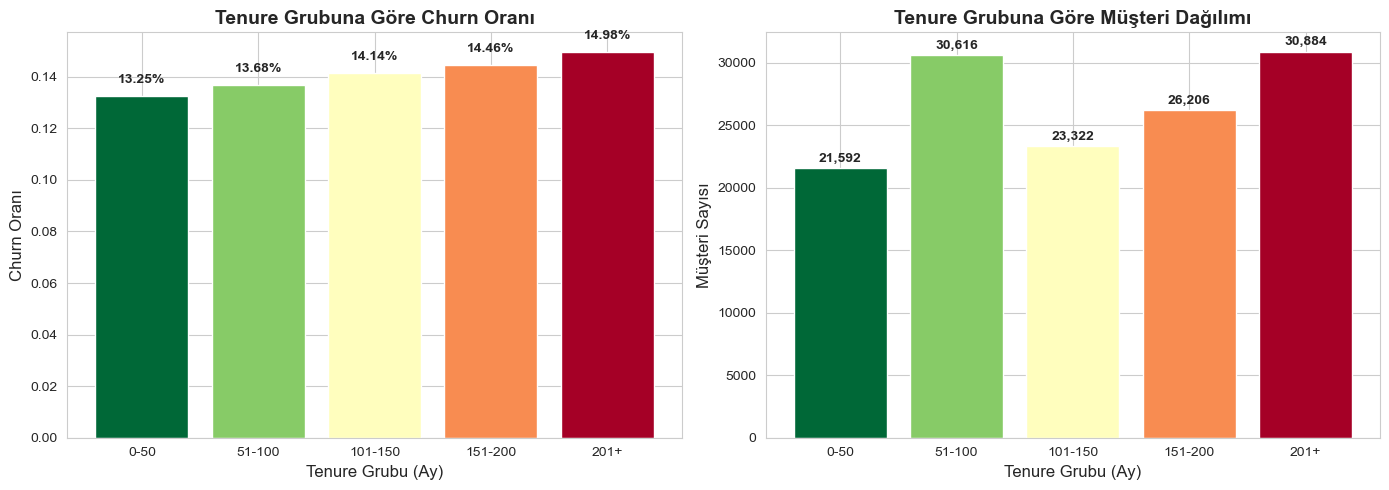


Tenure Grubuna Göre Churn İstatistikleri:
  tenure_group  churn_rate  count
0         0-50    0.132503  21592
1       51-100    0.136791  30616
2      101-150    0.141412  23322
3      151-200    0.144623  26206
4         201+    0.149754  30884


In [19]:
train_merged['tenure_group'] = pd.cut(train_merged['tenure'], 
                                        bins=[0, 50, 100, 150, 200, 300],
                                        labels=['0-50', '51-100', '101-150', '151-200', '201+'])

tenure_churn = train_merged.groupby('tenure_group')['churn'].agg(['mean', 'count']).reset_index()
tenure_churn.columns = ['tenure_group', 'churn_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(tenure_churn)), tenure_churn['churn_rate'], 
            color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(tenure_churn))))
axes[0].set_xticks(range(len(tenure_churn)))
axes[0].set_xticklabels(tenure_churn['tenure_group'])
axes[0].set_ylabel('Churn Oranı', fontsize=12)
axes[0].set_xlabel('Tenure Grubu (Ay)', fontsize=12)
axes[0].set_title('Tenure Grubuna Göre Churn Oranı', fontsize=14, fontweight='bold')
for i, v in enumerate(tenure_churn['churn_rate']):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

axes[1].bar(range(len(tenure_churn)), tenure_churn['count'], 
            color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(tenure_churn))))
axes[1].set_xticks(range(len(tenure_churn)))
axes[1].set_xticklabels(tenure_churn['tenure_group'])
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)
axes[1].set_xlabel('Tenure Grubu (Ay)', fontsize=12)
axes[1].set_title('Tenure Grubuna Göre Müşteri Dağılımı', fontsize=14, fontweight='bold')
for i, v in enumerate(tenure_churn['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTenure Grubuna Göre Churn İstatistikleri:")
print(tenure_churn)

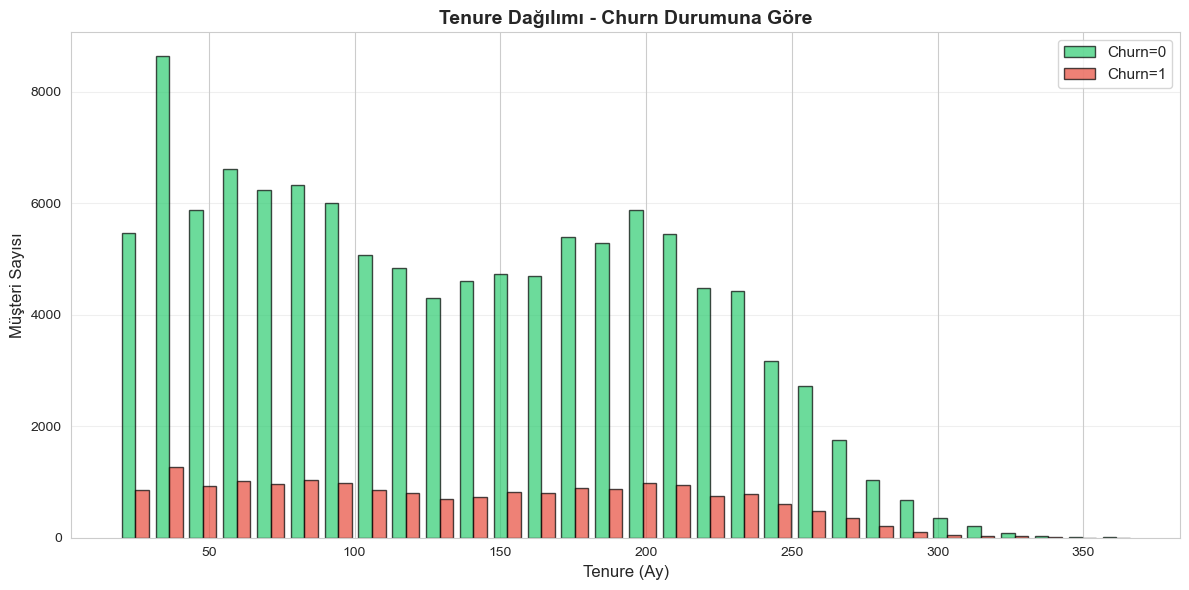


Tenure İstatistikleri - Churn Durumuna Göre:
Churn=0:
count    114417.000000
mean        134.773146
std          73.755686
min          19.000000
25%          70.000000
50%         131.000000
75%         196.000000
max         367.000000
Name: tenure, dtype: float64

Churn=1:
count    18870.000000
mean       138.667833
std         74.226724
min         19.000000
25%         72.000000
50%        135.000000
75%        201.000000
max        347.000000
Name: tenure, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
churn_0 = train_merged[train_merged['churn'] == 0]['tenure']
churn_1 = train_merged[train_merged['churn'] == 1]['tenure']

ax.hist([churn_0, churn_1], bins=30, label=['Churn=0', 'Churn=1'], 
        color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
ax.set_xlabel('Tenure (Ay)', fontsize=12)
ax.set_ylabel('Müşteri Sayısı', fontsize=12)
ax.set_title('Tenure Dağılımı - Churn Durumuna Göre', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTenure İstatistikleri - Churn Durumuna Göre:")
print("Churn=0:")
print(churn_0.describe())
print("\nChurn=1:")
print(churn_1.describe())

## 4. Özellik Mühendisliği

### 4.1 Veri Hazırlama ve Temel Özellikler

In [21]:
def create_features(ref_df, hist_df, cust_df, is_train=True):
    """
    Kapsamlı özellik mühendisliği fonksiyonu
    
    ÖNEMLİ: Data Leakage Önleme
    Bu fonksiyon her müşteri için SADECE ref_date tarihinden ÖNCEKİ 
    işlem verilerini kullanarak özellikler oluşturur.
    cust_hist['date'] < ref_date filtresi ile gelecek verisi kesinlikle dahil edilmez.
    """
    print("Özellik mühendisliği başlıyor...")
    
    # Tarihleri datetime'a çevir
    hist_df = hist_df.copy()
    hist_df['date'] = pd.to_datetime(hist_df['date'])
    ref_df = ref_df.copy()
    ref_df['ref_date'] = pd.to_datetime(ref_df['ref_date'])
    
    # NaN değerleri 0 ile doldur
    hist_df['mobile_eft_all_cnt'] = hist_df['mobile_eft_all_cnt'].fillna(0)
    hist_df['mobile_eft_all_amt'] = hist_df['mobile_eft_all_amt'].fillna(0)
    hist_df['cc_transaction_all_cnt'] = hist_df['cc_transaction_all_cnt'].fillna(0)
    hist_df['cc_transaction_all_amt'] = hist_df['cc_transaction_all_amt'].fillna(0)
    
    # Müşteri bazında özet özellikler
    features_list = []
    
    for idx, row in tqdm(ref_df.iterrows(), total=len(ref_df), desc="Özellikler oluşturuluyor"):
        cust_id = row['cust_id']
        ref_date = row['ref_date']
        
        # KRİTİK: Sadece ref_date'den ÖNCEKİ verileri kullan (Data Leakage Önleme)
        # Bu filtre sayesinde model "geleceği görmüş" olmaz
        cust_hist = hist_df[(hist_df['cust_id'] == cust_id) & (hist_df['date'] < ref_date)].copy()
        
        if len(cust_hist) == 0:
            continue
            
        # Zaman farkları
        cust_hist['days_to_ref'] = (ref_date - cust_hist['date']).dt.days
        cust_hist['months_to_ref'] = cust_hist['days_to_ref'] / 30
        
        # Son 6 ay ve tüm geçmiş
        last_6m = cust_hist[cust_hist['months_to_ref'] <= 6]
        last_3m = cust_hist[cust_hist['months_to_ref'] <= 3]
        last_12m = cust_hist[cust_hist['months_to_ref'] <= 12]
        
        feat_dict = {'cust_id': cust_id}
        
        # === RFM ÖZELLİKLERİ ===
        # Recency (En son işlem)
        feat_dict['recency_days'] = cust_hist['days_to_ref'].min()
        feat_dict['recency_last_6m'] = last_6m['days_to_ref'].min() if len(last_6m) > 0 else 180
        feat_dict['recency_last_3m'] = last_3m['days_to_ref'].min() if len(last_3m) > 0 else 90
        
        # Frequency (İşlem sıklığı)
        feat_dict['total_records'] = len(cust_hist)
        feat_dict['records_last_6m'] = len(last_6m)
        feat_dict['records_last_3m'] = len(last_3m)
        feat_dict['records_last_12m'] = len(last_12m)
        
        # Monetary (Parasal değer)
        feat_dict['total_mobile_eft_amt'] = cust_hist['mobile_eft_all_amt'].sum()
        feat_dict['total_cc_amt'] = cust_hist['cc_transaction_all_amt'].sum()
        feat_dict['avg_mobile_eft_amt'] = cust_hist['mobile_eft_all_amt'].mean()
        feat_dict['avg_cc_amt'] = cust_hist['cc_transaction_all_amt'].mean()
        
        # Son 6 ay monetary
        feat_dict['total_mobile_eft_amt_6m'] = last_6m['mobile_eft_all_amt'].sum() if len(last_6m) > 0 else 0
        feat_dict['total_cc_amt_6m'] = last_6m['cc_transaction_all_amt'].sum() if len(last_6m) > 0 else 0
        feat_dict['avg_mobile_eft_amt_6m'] = last_6m['mobile_eft_all_amt'].mean() if len(last_6m) > 0 else 0
        feat_dict['avg_cc_amt_6m'] = last_6m['cc_transaction_all_amt'].mean() if len(last_6m) > 0 else 0
        
        # === ÜRÜN ÖZELLİKLERİ ===
        feat_dict['avg_products'] = cust_hist['active_product_category_nbr'].mean()
        feat_dict['max_products'] = cust_hist['active_product_category_nbr'].max()
        feat_dict['min_products'] = cust_hist['active_product_category_nbr'].min()
        feat_dict['std_products'] = cust_hist['active_product_category_nbr'].std()
        
        # Son dönem ürün özellikleri
        feat_dict['avg_products_6m'] = last_6m['active_product_category_nbr'].mean() if len(last_6m) > 0 else 0
        feat_dict['avg_products_3m'] = last_3m['active_product_category_nbr'].mean() if len(last_3m) > 0 else 0
        
        # Ürün trendi
        if len(last_3m) > 0 and feat_dict['avg_products'] > 0:
            feat_dict['product_trend'] = feat_dict['avg_products_3m'] - feat_dict['avg_products']
        else:
            feat_dict['product_trend'] = 0
            
        # === İŞLEM SAYISI ÖZELLİKLERİ ===
        feat_dict['total_mobile_eft_cnt'] = cust_hist['mobile_eft_all_cnt'].sum()
        feat_dict['total_cc_cnt'] = cust_hist['cc_transaction_all_cnt'].sum()
        feat_dict['avg_mobile_eft_cnt'] = cust_hist['mobile_eft_all_cnt'].mean()
        feat_dict['avg_cc_cnt'] = cust_hist['cc_transaction_all_cnt'].mean()
        
        # Son 6 ay işlem sayıları
        feat_dict['total_mobile_eft_cnt_6m'] = last_6m['mobile_eft_all_cnt'].sum() if len(last_6m) > 0 else 0
        feat_dict['total_cc_cnt_6m'] = last_6m['cc_transaction_all_cnt'].sum() if len(last_6m) > 0 else 0
        feat_dict['avg_mobile_eft_cnt_6m'] = last_6m['mobile_eft_all_cnt'].mean() if len(last_6m) > 0 else 0
        feat_dict['avg_cc_cnt_6m'] = last_6m['cc_transaction_all_cnt'].mean() if len(last_6m) > 0 else 0
        
        # === TREND ÖZELLİKLERİ ===
        # Aktivite trendi (son 3 ay vs önceki)
        if len(last_6m) > 0:
            prev_3m = last_6m[last_6m['months_to_ref'] > 3]
            if len(prev_3m) > 0 and len(last_3m) > 0:
                feat_dict['mobile_eft_trend'] = last_3m['mobile_eft_all_amt'].mean() - prev_3m['mobile_eft_all_amt'].mean()
                feat_dict['cc_trend'] = last_3m['cc_transaction_all_amt'].mean() - prev_3m['cc_transaction_all_amt'].mean()
                feat_dict['activity_trend'] = len(last_3m) - len(prev_3m)
            else:
                feat_dict['mobile_eft_trend'] = 0
                feat_dict['cc_trend'] = 0
                feat_dict['activity_trend'] = 0
        else:
            feat_dict['mobile_eft_trend'] = 0
            feat_dict['cc_trend'] = 0
            feat_dict['activity_trend'] = 0
        
        # === ORAN ÖZELLİKLERİ ===
        # İşlem başına ortalama tutar
        if feat_dict['avg_mobile_eft_cnt'] > 0:
            feat_dict['mobile_eft_amt_per_txn'] = feat_dict['avg_mobile_eft_amt'] / feat_dict['avg_mobile_eft_cnt']
        else:
            feat_dict['mobile_eft_amt_per_txn'] = 0
            
        if feat_dict['avg_cc_cnt'] > 0:
            feat_dict['cc_amt_per_txn'] = feat_dict['avg_cc_amt'] / feat_dict['avg_cc_cnt']
        else:
            feat_dict['cc_amt_per_txn'] = 0
        
        # CC vs Mobile EFT oranı
        total_amt = feat_dict['total_mobile_eft_amt'] + feat_dict['total_cc_amt']
        if total_amt > 0:
            feat_dict['cc_ratio'] = feat_dict['total_cc_amt'] / total_amt
        else:
            feat_dict['cc_ratio'] = 0
            
        # === İSTATİSTİKSEL ÖZELLİKLER ===
        feat_dict['std_mobile_eft_amt'] = cust_hist['mobile_eft_all_amt'].std()
        feat_dict['std_cc_amt'] = cust_hist['cc_transaction_all_amt'].std()
        feat_dict['max_mobile_eft_amt'] = cust_hist['mobile_eft_all_amt'].max()
        feat_dict['max_cc_amt'] = cust_hist['cc_transaction_all_amt'].max()
        
        # Sıfır işlem oranı
        feat_dict['zero_mobile_eft_ratio'] = (cust_hist['mobile_eft_all_cnt'] == 0).mean()
        feat_dict['zero_cc_ratio'] = (cust_hist['cc_transaction_all_cnt'] == 0).mean()
        
        features_list.append(feat_dict)
    
    # DataFrame'e çevir
    features_df = pd.DataFrame(features_list)
    
    # Demografik bilgileri ekle
    features_df = features_df.merge(cust_df, on='cust_id', how='left')
    
    # work_sector NaN'ları doldur
    features_df['work_sector'] = features_df['work_sector'].fillna('Unknown')
    
    # Referans bilgilerini ekle
    features_df = features_df.merge(ref_df[['cust_id', 'ref_date']], on='cust_id', how='left')
    
    if is_train:
        features_df = features_df.merge(ref_df[['cust_id', 'churn']], on='cust_id', how='left')
    
    print(f"Toplam {len(features_df)} müşteri için {features_df.shape[1]} özellik oluşturuldu!")
    
    return features_df

# Train ve test özellikleri oluştur
train_features = create_features(referance_train_df, customers_hist_df, customers_df, is_train=True)
test_features = create_features(referance_test_df, customers_hist_df, customers_df, is_train=False)

print("\n" + "="*60)
print("Train Features Shape:", train_features.shape)
print("Test Features Shape:", test_features.shape)
print("="*60)

Özellik mühendisliği başlıyor...


Özellikler oluşturuluyor: 100%|██████████| 133287/133287 [2:18:36<00:00, 16.03it/s]     


Toplam 133287 müşteri için 52 özellik oluşturuldu!
Özellik mühendisliği başlıyor...


Özellikler oluşturuluyor: 100%|██████████| 43006/43006 [54:19<00:00, 13.19it/s]     


Toplam 43006 müşteri için 51 özellik oluşturuldu!

Train Features Shape: (133287, 52)
Test Features Shape: (43006, 51)


In [22]:
print("Train Features İlk 5 Satır:")
print(train_features.head())
print("\nÖzellik İsimleri:")
print(train_features.columns.tolist())
print("\nEksik Değerler:")
print(train_features.isnull().sum()[train_features.isnull().sum() > 0])

Train Features İlk 5 Satır:
   cust_id  recency_days  recency_last_6m  recency_last_3m  total_records  \
0        0            31               31               31             20   
1        3            30               30               30             33   
2        5            28               28               28             26   
3        6            31               31               31             27   
4        7            30               30               30             28   

   records_last_6m  records_last_3m  records_last_12m  total_mobile_eft_amt  \
0                5                2                11               2365.69   
1                5                2                11               1971.62   
2                5                3                11               9710.94   
3                5                3                11              15048.12   
4                5                3                11                546.18   

   total_cc_amt  ...  zero_cc_rati

### 4.2 Özellik Korelasyon Analizi

Top 20 Özellik - Churn Korelasyonu:
avg_products               0.211888
avg_products_6m            0.198425
avg_products_3m            0.196940
min_products               0.188832
max_products               0.167961
total_mobile_eft_cnt_6m    0.053925
avg_mobile_eft_cnt_6m      0.053925
total_mobile_eft_cnt       0.052361
avg_mobile_eft_cnt         0.051683
max_mobile_eft_amt         0.039381
total_mobile_eft_amt_6m    0.037624
avg_mobile_eft_amt_6m      0.037624
total_mobile_eft_amt       0.037333
avg_mobile_eft_amt         0.036858
std_mobile_eft_amt         0.036829
std_products               0.031086
age                        0.030268
total_cc_cnt               0.028408
total_records              0.025292
avg_cc_cnt_6m              0.025001
Name: churn, dtype: float64


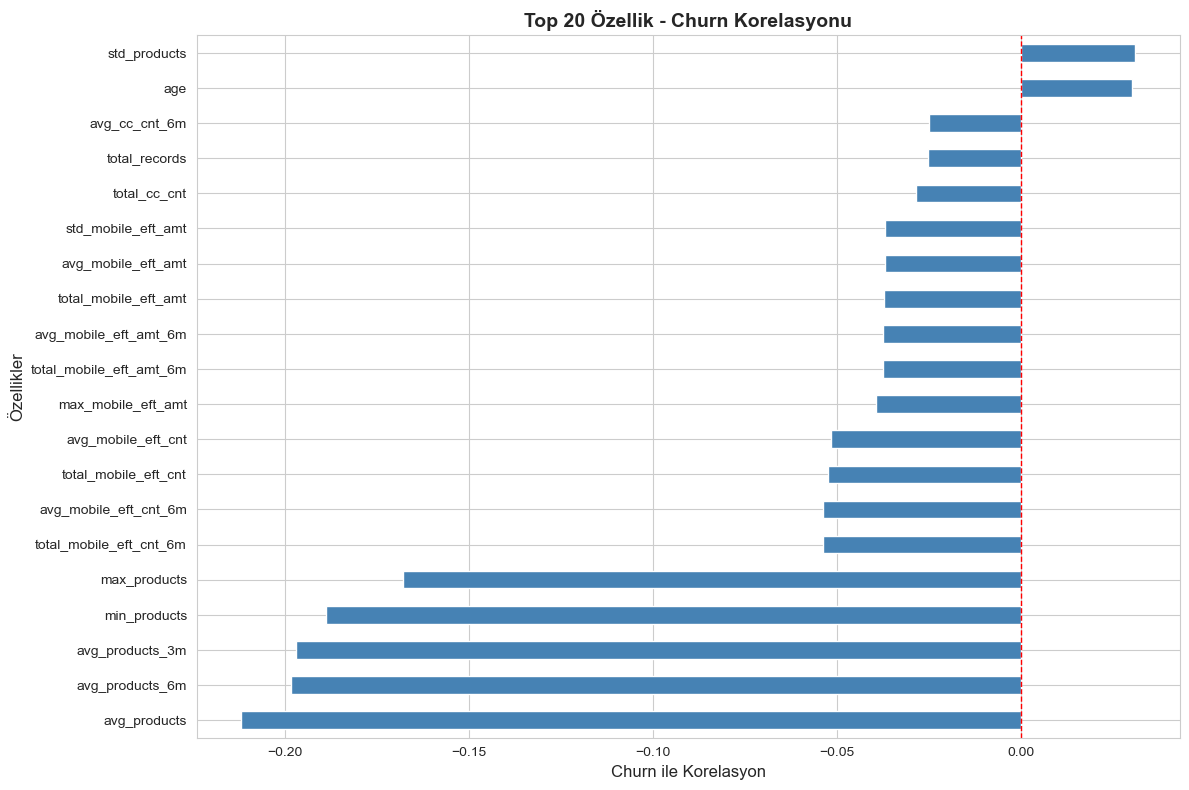

In [23]:
numeric_features = train_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['cust_id', 'churn']]

feature_corr = train_features[numeric_features + ['churn']].corr()['churn'].drop('churn')
feature_corr_sorted = feature_corr.abs().sort_values(ascending=False)

print("Top 20 Özellik - Churn Korelasyonu:")
print(feature_corr_sorted.head(20))

plt.figure(figsize=(12, 8))
top_features = feature_corr_sorted.head(20).index
feature_corr[top_features].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Churn ile Korelasyon', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.title('Top 20 Özellik - Churn Korelasyonu', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## 5. Özellik Seçimi

### 5.1 Welch's T-test ile Özellik Seçimi

In [24]:
def welch_ttest_feature_selection(df, target_col='churn', p_value_threshold=0.05):
    """
    Welch's T-test kullanarak özellik seçimi yapar
    """
    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_features = [f for f in numeric_features if f not in ['cust_id', target_col]]
    
    results = []
    
    for feature in numeric_features:
        # NaN değerleri çıkar
        valid_data = df[[feature, target_col]].dropna()
        
        if len(valid_data) == 0:
            continue
            
        group_0 = valid_data[valid_data[target_col] == 0][feature]
        group_1 = valid_data[valid_data[target_col] == 1][feature]
        
        if len(group_0) > 0 and len(group_1) > 0:
            # Welch's t-test (eşit varyans varsayımı olmadan)
            t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)
            
            results.append({
                'feature': feature,
                't_statistic': t_stat,
                'p_value': p_value,
                'mean_churn_0': group_0.mean(),
                'mean_churn_1': group_1.mean(),
                'mean_diff': abs(group_0.mean() - group_1.mean())
            })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('p_value')
    
    # Anlamlı özellikleri seç
    significant_features = results_df[results_df['p_value'] < p_value_threshold]['feature'].tolist()
    
    print(f"Toplam {len(numeric_features)} özellikten {len(significant_features)} tanesi anlamlı (p < {p_value_threshold})")
    
    return results_df, significant_features

# Welch's T-test uygula
ttest_results, significant_features = welch_ttest_feature_selection(train_features)

print("\nEn Anlamlı 20 Özellik:")
print(ttest_results.head(20))

Toplam 44 özellikten 37 tanesi anlamlı (p < 0.05)

En Anlamlı 20 Özellik:
                    feature  t_statistic        p_value  mean_churn_0  \
17             min_products    90.617477   0.000000e+00      2.414799   
15             avg_products    84.644387   0.000000e+00      2.726624   
16             max_products    63.301519   0.000000e+00      2.923237   
19          avg_products_6m    78.063609   0.000000e+00      2.714570   
20          avg_products_3m    77.671479   0.000000e+00      2.699609   
26  total_mobile_eft_cnt_6m    23.799602  4.553456e-124     15.190793   
28    avg_mobile_eft_cnt_6m    23.799602  4.553456e-124      3.038159   
22     total_mobile_eft_cnt    22.285203  4.152536e-109     80.028484   
24       avg_mobile_eft_cnt    22.149633  7.955370e-108      3.015554   
38       max_mobile_eft_amt    15.823917   3.755652e-56   1292.725980   
13    avg_mobile_eft_amt_6m    15.740139   1.369391e-55    499.168648   
11  total_mobile_eft_amt_6m    15.740139   1.36939

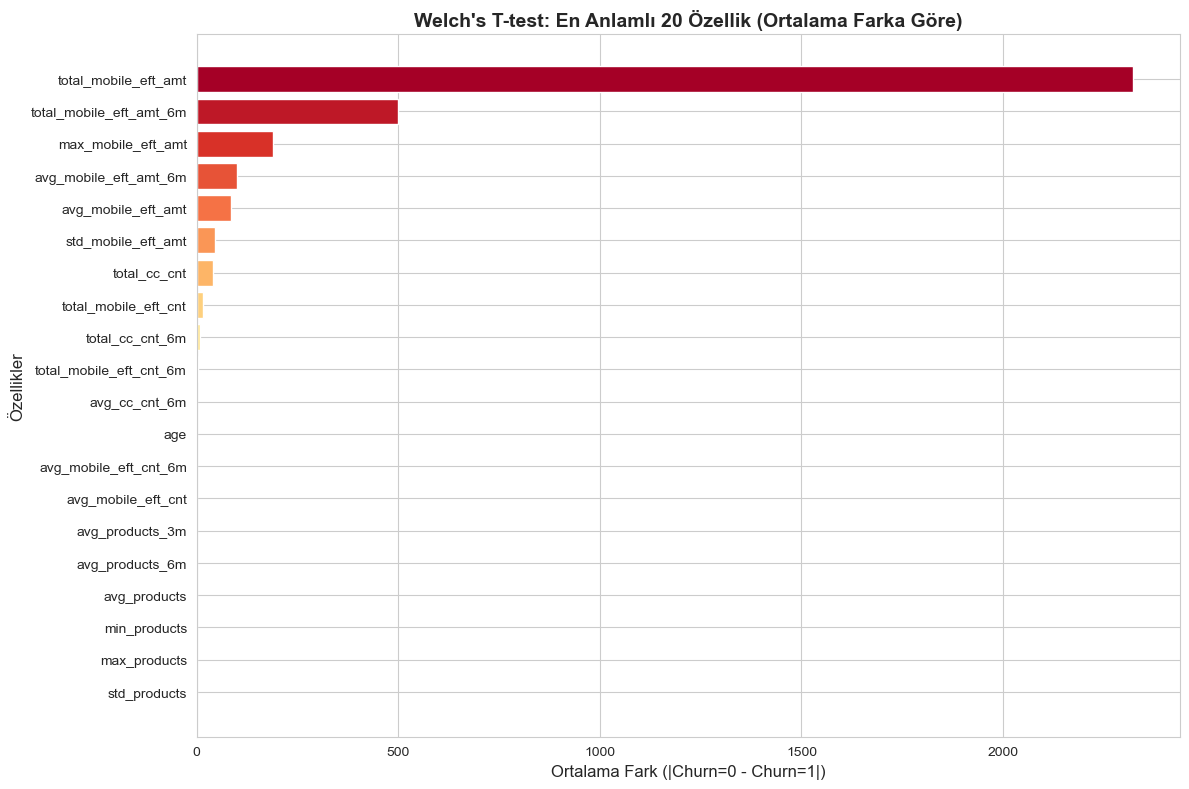

In [25]:
plt.figure(figsize=(12, 8))
top_20_ttest = ttest_results.head(20).copy()
top_20_ttest = top_20_ttest.sort_values('mean_diff', ascending=True)

plt.barh(range(len(top_20_ttest)), top_20_ttest['mean_diff'], 
         color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_20_ttest))))
plt.yticks(range(len(top_20_ttest)), top_20_ttest['feature'])
plt.xlabel('Ortalama Fark (|Churn=0 - Churn=1|)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.title("Welch's T-test: En Anlamlı 20 Özellik (Ortalama Farka Göre)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım ve Neden:** Ürettiğimiz onlarca özelliği istatistiksel testlerden geçirerek churn eden ve etmeyen müşteriler arasında gerçekten anlamlı fark yaratanları süzdük. Amacımız, modeli gürültüden (noise) arındırmak, eğitim süresini hızlandırmak ve çok fazla özellikten kaynaklanabilecek aşırı öğrenmenin (overfitting) önüne geçmekti.

### 5.2 Model Hazırlığı - Özellik ve Kategorik Değişkenler

In [26]:
# Kategorik ve numerik özellikleri ayır
categorical_features = ['gender', 'province', 'religion', 'work_type', 'work_sector']
numeric_features_final = [f for f in significant_features if f not in categorical_features]

# Tüm özellikler
all_features = numeric_features_final + categorical_features

print(f"Toplam Özellik Sayısı: {len(all_features)}")
print(f"Numerik Özellikler: {len(numeric_features_final)}")
print(f"Kategorik Özellikler: {len(categorical_features)}")
print(f"\nKategorik Özellikler: {categorical_features}")

Toplam Özellik Sayısı: 42
Numerik Özellikler: 37
Kategorik Özellikler: 5

Kategorik Özellikler: ['gender', 'province', 'religion', 'work_type', 'work_sector']


## 6. Modelleme ve Çapraz Doğrulama

### 6.1 CatBoost Model ile Cross-Validation

In [27]:
# Train verisi hazırlama
X_train = train_features[all_features].copy()
y_train = train_features['churn'].copy()

# NaN değerleri doldur
for col in numeric_features_final:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(X_train[col].median())

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Churn oranı: {y_train.mean():.4f}")

X_train shape: (133287, 42)
y_train shape: (133287,)
Churn oranı: 0.1416


In [29]:
# CatBoost parametreleri
catboost_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'min_data_in_leaf': 20,
    'random_strength': 0.5,
    'bagging_temperature': 0.2,
    'od_type': 'Iter',
    'od_wait': 50,
    'auto_class_weights':'Balanced',
    'random_seed': 42,
    'verbose': 100,
    'task_type': 'CPU',
    'cat_features': categorical_features,
    'eval_metric': 'AUC',
    'use_best_model': True
}

# Cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(test_features))
fold_scores = []
models = []

print("\n" + "="*60)
print(f"CatBoost {n_splits}-Fold Cross-Validation Başlıyor...")
print("="*60 + "\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n{'='*60}")
    print(f"Fold {fold}/{n_splits}")
    print(f"{'='*60}")
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # CatBoost model
    model = CatBoostClassifier(**catboost_params)
    
    # Train
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=100
    )
    
    # OOF predictions
    oof_predictions[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # Test predictions
    test_predictions += model.predict_proba(test_features[all_features].fillna(0))[:, 1] / n_splits
    
    # Fold score
    fold_score = ing_hubs_datathon_metric(y_val, oof_predictions[val_idx])
    fold_scores.append(fold_score)
    
    print(f"\nFold {fold} Custom Score: {fold_score:.6f}")
    print(f"Fold {fold} AUC: {roc_auc_score(y_val, oof_predictions[val_idx]):.6f}")
    
    models.append(model)

# Overall OOF score
oof_score = ing_hubs_datathon_metric(y_train, oof_predictions)
oof_auc = roc_auc_score(y_train, oof_predictions)

print("\n" + "="*60)
print("CROSS-VALIDATION SONUÇLARI")
print("="*60)
print(f"\nFold Skorları: {[f'{s:.6f}' for s in fold_scores]}")
print(f"Ortalama Fold Skoru: {np.mean(fold_scores):.6f} (+/- {np.std(fold_scores):.6f})")
print(f"\nOOF Custom Score: {oof_score:.6f}")
print(f"OOF AUC: {oof_auc:.6f}")
print(f"OOF Gini: {convert_auc_to_gini(oof_auc):.6f}")
print("="*60)


CatBoost 5-Fold Cross-Validation Başlıyor...


Fold 1/5
0:	test: 0.6971210	best: 0.6971210 (0)	total: 287ms	remaining: 4m 46s
100:	test: 0.7136737	best: 0.7136902 (95)	total: 11.6s	remaining: 1m 43s
200:	test: 0.7147762	best: 0.7148491 (194)	total: 22.8s	remaining: 1m 30s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7149914381
bestIteration = 221

Shrink model to first 222 iterations.

Fold 1 Custom Score: 1.173010
Fold 1 AUC: 0.714991

Fold 2/5
0:	test: 0.6880463	best: 0.6880463 (0)	total: 111ms	remaining: 1m 50s
100:	test: 0.7081916	best: 0.7082871 (97)	total: 11.3s	remaining: 1m 40s
200:	test: 0.7088565	best: 0.7090269 (181)	total: 22.5s	remaining: 1m 29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7090440328
bestIteration = 225

Shrink model to first 226 iterations.

Fold 2 Custom Score: 1.144303
Fold 2 AUC: 0.709044

Fold 3/5
0:	test: 0.6821997	best: 0.6821997 (0)	total: 113ms	remaining: 1m 52s
100:	test: 0.7067204	best: 0.7067689 (9

### 6.2 Cross-Validation Sonuçları Görselleştirme

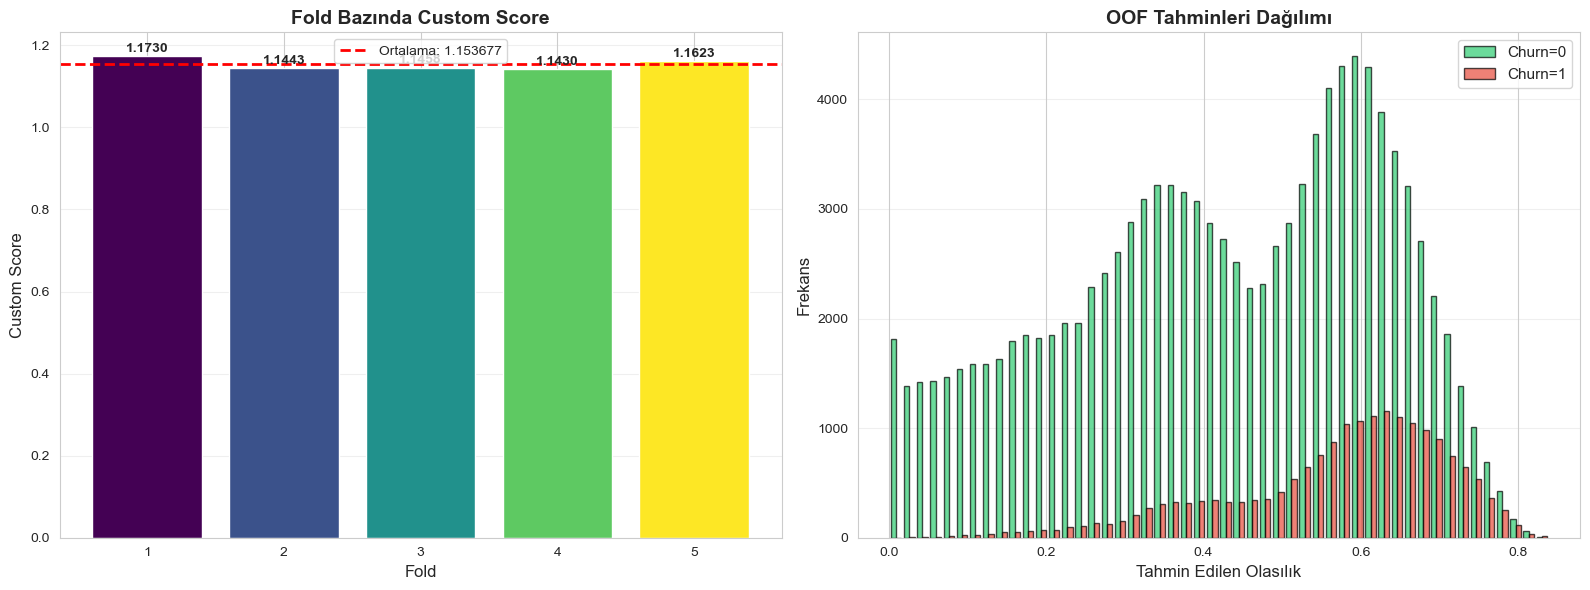

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fold skorları
axes[0].bar(range(1, n_splits + 1), fold_scores, color=plt.cm.viridis(np.linspace(0, 1, n_splits)))
axes[0].axhline(y=np.mean(fold_scores), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {np.mean(fold_scores):.6f}')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Custom Score', fontsize=12)
axes[0].set_title('Fold Bazında Custom Score', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(fold_scores):
    axes[0].text(i + 1, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# OOF predictions dağılımı
axes[1].hist([oof_predictions[y_train == 0], oof_predictions[y_train == 1]], 
             bins=50, label=['Churn=0', 'Churn=1'], 
             color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Tahmin Edilen Olasılık', fontsize=12)
axes[1].set_ylabel('Frekans', fontsize=12)
axes[1].set_title('OOF Tahminleri Dağılımı', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Açıklanabilirliği

Modelin kararlarını neye göre verdiğini SHAP ve özellik önemi (feature importance) grafikleriyle görselleştirdik. Modeli bir **kara kutu** olmaktan çıkararak, bankanın iş birimlerine müşteri kaybını önlemeleri için doğrudan çıkarımlar (örnek vermek gerekirse "son 3 aydaki ürün kullanım düşüşü en büyük terk etme tetikleyicisidir.") sağlamayı hedefledik.

### 7.1 Feature Importance

Top 30 En Önemli Özellik:
                    feature  importance
1              avg_products   11.458618
0              min_products    9.869627
2              max_products    8.308387
3           avg_products_6m    6.404772
16             std_products    5.417073
6     avg_mobile_eft_cnt_6m    4.773650
18            avg_cc_cnt_6m    4.588236
4           avg_products_3m    4.264121
5   total_mobile_eft_cnt_6m    4.028667
21            total_records    3.901341
19          total_cc_cnt_6m    3.722411
23            product_trend    3.047455
25         mobile_eft_trend    2.949243
7      total_mobile_eft_cnt    2.211351
8        avg_mobile_eft_cnt    2.109169
20               avg_cc_cnt    1.993210
17                      age    1.819290
33                 cc_trend    1.774738
10    avg_mobile_eft_amt_6m    1.494420
15             total_cc_cnt    1.279505
11  total_mobile_eft_amt_6m    1.215815
31               avg_cc_amt    1.064017
26             total_cc_amt    1.020404
29            

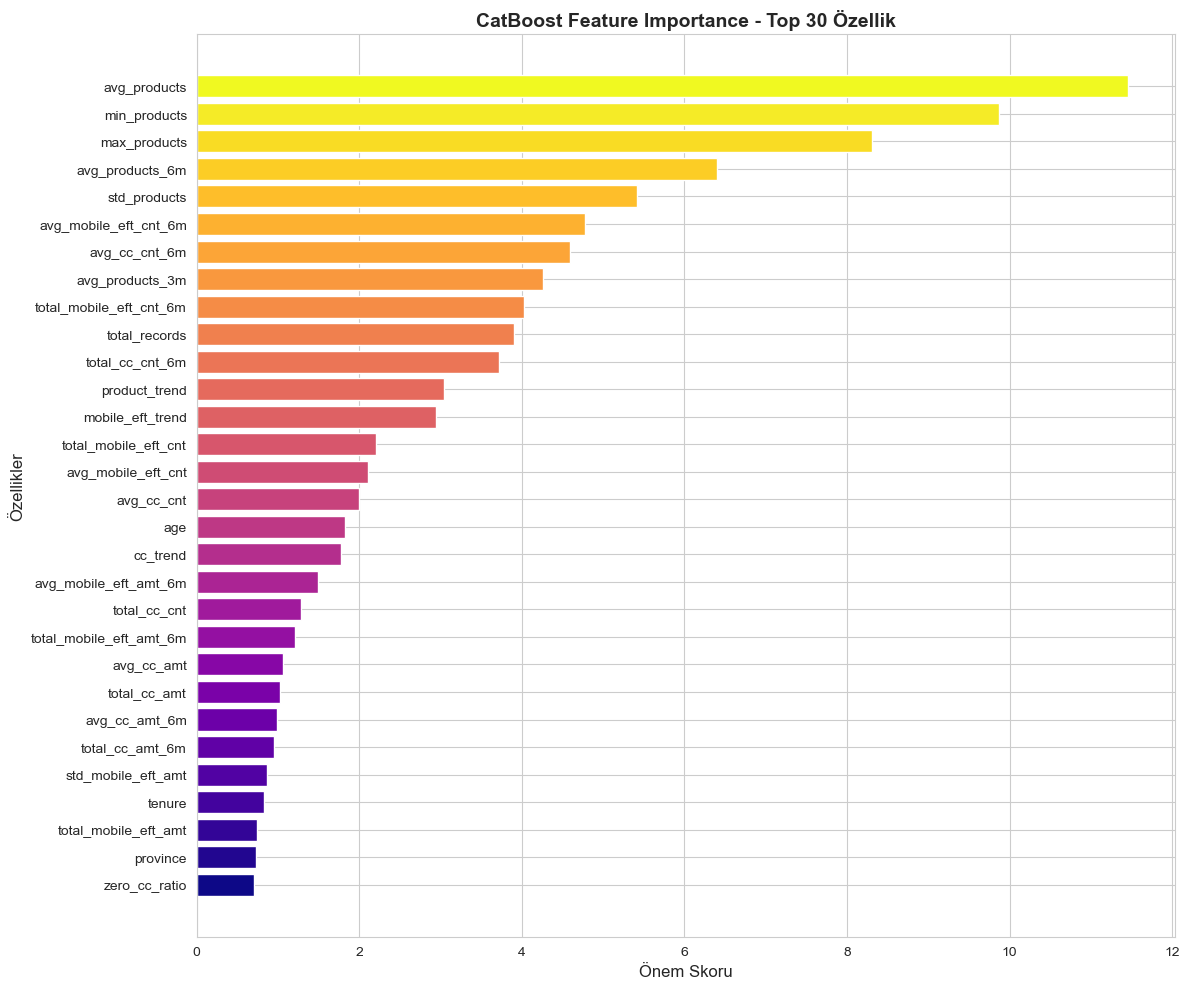

In [31]:
# Tüm modellerin feature importance'ını ortala
feature_importance_list = []

for i, model in enumerate(models):
    fi = model.get_feature_importance()
    feature_importance_list.append(fi)

avg_feature_importance = np.mean(feature_importance_list, axis=0)

# DataFrame oluştur
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': avg_feature_importance
})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Top 30 En Önemli Özellik:")
print(feature_importance_df.head(30))

# Görselleştirme
plt.figure(figsize=(12, 10))
top_30 = feature_importance_df.head(30).sort_values('importance', ascending=True)
plt.barh(range(len(top_30)), top_30['importance'], 
         color=plt.cm.plasma(np.linspace(0, 1, len(top_30))))
plt.yticks(range(len(top_30)), top_30['feature'])
plt.xlabel('Önem Skoru', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.title('CatBoost Feature Importance - Top 30 Özellik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 SHAP Analizi

In [32]:
# İlk modeli kullanarak SHAP analizi (hız için sample alıyoruz)
print("SHAP değerleri hesaplanıyor...")
sample_size = min(1000, len(X_train))
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train.iloc[sample_indices]

# SHAP explainer
explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X_sample)

print("SHAP analizi tamamlandı!")

SHAP değerleri hesaplanıyor...
SHAP analizi tamamlandı!


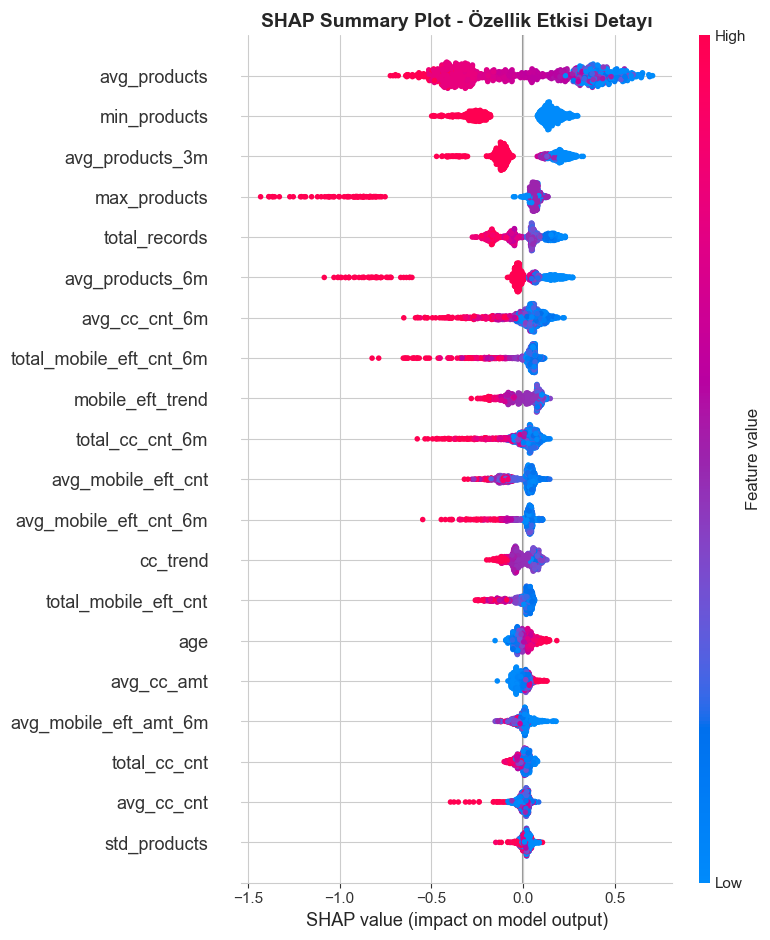

In [33]:
# SHAP Summary Plot (detailed)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot - Özellik Etkisi Detayı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Test Tahminleme ve Submission

In [35]:
# Submission dosyası oluştur
submission = pd.DataFrame({
    'cust_id': test_features['cust_id'],
    'churn': test_predictions
})

# Churn ihtimaline göre sırala (yüksekten düşüğe)
submission = submission.sort_values('churn', ascending=False).reset_index(drop=True)

print("Submission Özeti:")
print(submission.head(10))
print(f"\nToplam tahmin sayısı: {len(submission)}")
print(f"Ortalama tahmin: {submission['churn'].mean():.6f}")
print(f"Min tahmin: {submission['churn'].min():.6f}")
print(f"Max tahmin: {submission['churn'].max():.6f}")

# Dosyaya kaydet
submission.to_csv('submission.csv', index=False)
print("\nSubmission dosyası 'submission.csv' olarak kaydedildi!")

Submission Özeti:
   cust_id     churn
0    18985  0.794119
1   139195  0.787572
2   137015  0.781851
3    64509  0.778368
4    74704  0.775380
5    37299  0.773943
6   142222  0.768025
7    41546  0.767266
8    16085  0.766875
9   158757  0.766832

Toplam tahmin sayısı: 43006
Ortalama tahmin: 0.412513
Min tahmin: 0.000594
Max tahmin: 0.794119

Submission dosyası 'submission.csv' olarak kaydedildi!


## 9. Özet ve Sonuçlar

Bu çalışmada, müşteri kaybı tahminine yönelik detaylı bir analiz yaptım. Veri setimiz 176 bin müşteriyi içeriyor ve bunların yaklaşık %14'ü müşteri kaybına uğramış durumda. Bu oran, aslında oldukça dengesiz bir dağılım oluşturuyor ki bu da modelleme aşamasında üzerinde durulması gereken önemli bir nokta.

Veri analizinde dikkat çekici sonuçlar elde edildi. Örneğin, 56 yaş ve üzerindeki müşterilerin churn oranı %15.5’e kadar yükseliyor. Cinsiyet açısından belirgin bir fark bulunmamakla birlikte, iş durumunun etkisi oldukça belirgin; emeklilerde bu oran %16.5 ile en yüksek seviyede. Work_sector kolonundaki eksik değerler de ilginç bir şekilde churn için anlamlı bir sinyal veriyor, istatistiksel testler bunu doğruluyor.

Müşteri davranışları incelendiğinde ürün çeşitliliğinin önemli olduğu görülüyor. Daha fazla ürün kullanan müşterilerde churn oranı belirgin şekilde düşük. Ayrıca son 3 aydaki aktivite seviyesi de kritik bir gösterge olarak öne çıkıyor.

Özellik mühendisliği sürecinde, data leakage'a odaklandım. Modelin gelecekteki bilgilerine ulaşmaması için, tüm özelliklerin ref_date'den önce hesaplanmasını sağladım. RFM analizi ile birlikte zamansal eğilimler ve ürün ile işlem kalıpları gibi farklı unsurlar üzerinde de durdum. Welch's T-test yöntemleriyle de özellik seçimi yaptım.

Model olarak CatBoost kullandım ve 5-fold cross validation ile değerlendirdim. Yarışmanın özel metriği Gini, Recall@10% ve Lift@10% değerlerinin ağırlıklı ortalamasından oluşuyor. SHAP analizi ile de modelin tahminlerini açıklanabilir hale getirmeye çalıştım.

## 10. Geliştirme Fikirleri

MModellerimi geliştirmek için bazı fikirlerim var. Şu an sadece CatBoost kullanıyorum, ancak LightGBM ve XGBoost'u da deneyip bunları birleştirebilirim. Weighted averaging veya stacking yöntemiyle farklı modellerin güçlü yanlarını birleştirebilirim.

Özellik mühendisliği alanında henüz pek çok fırsat mevcut. Örneğin, şu anda 3, 6 ve 12 aylık dönemler üzerinden değerlendiriyorum; ancak son bir aydaki davranışlar oldukça önemli olabilir. Bunun yanı sıra, ilk üç ay ile son üç ayı karşılaştırarak trend özelliklerini belirleyebilirim.

Feature selection kısmını da geliştirebilirim. Şu an Welch's T-test kullanıyorum ama LOFO importance, permutation importance veya SHAP-based feature selection ile daha detaylı bir seçim yapabilirim. Bazı düşük önemli özellikleri çıkarmak modelin generalization yeteneğini artırabilir.

Hiperparametre optimizasyonu için Optuna vs. kullanabilirim. Şu anki parametreler iyi çalışıyor ama daha geniş bir arama uzayında Bayesian optimization ile daha iyisini bulabilirim.

Hızlıca deneyebileceğim birkaç şey var: son 1 ay özelliklerini eklemek ve en az 2-3 farklı modeli ensemble etmek. Bunlar nispeten kolay uygulanabilir ve skorumda hızlı bir iyileşme sağlayabilir.